# ***SETUP***

In [2]:
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive')

# Base directory
base_path = "/content/drive/MyDrive/CIC_IOV_2024"

# List of subfolders
folders = [
    "artifacts",
    "lime",
    "shap",
    "models",
    "plots",
    "processed",
    "raw",
    "report"
]

# main folder
os.makedirs(base_path, exist_ok=True)

for folder in folders:
    os.makedirs(os.path.join(base_path, folder), exist_ok=True)

print("Folder structure created successfully!")

Mounted at /content/drive
Folder structure created successfully!


In [3]:
!pip install numpy pandas scikit-learn matplotlib seaborn joblib

# ML Models
!pip install xgboost lightgbm catboost

# Feature Selection (PSO)
!pip install niapy==2.0.0rc17

# Explainability
!pip install shap

# For large datasets
!pip install tqdm

# Complete one-liner:
!pip install numpy pandas scikit-learn matplotlib seaborn joblib xgboost lightgbm catboost niapy==2.0.0rc17 shap tqdm

!pip install lime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.7/200.7 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=8806d93cc22f1dfc0bac30dc5a5c4cef99b008fad3e624deca37be777366576c
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


# **LIBRARY IMPORTS**

In [4]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from time import time
warnings.filterwarnings('ignore')

# Core ML
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelBinarizer
from imblearn.over_sampling import SMOTE

# Model variety
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import AdaBoostClassifier
import xgboost as xgb
import lightgbm as lgb
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import joblib

# Explainability
import shap
import lime
import lime.lime_tabular


In [7]:
input_files = [
    "/content/drive/MyDrive/CIC_IOV_2024/raw/decimal_DoS.csv",
    "/content/drive/MyDrive/CIC_IOV_2024/raw/decimal_benign.csv",
    "/content/drive/MyDrive/CIC_IOV_2024/raw/decimal_spoofing-GAS.csv",
    "/content/drive/MyDrive/CIC_IOV_2024/raw/decimal_spoofing-RPM.csv",
    "/content/drive/MyDrive/CIC_IOV_2024/raw/decimal_spoofing-SPEED.csv",
    "/content/drive/MyDrive/CIC_IOV_2024/raw/decimal_spoofing-STEERING_WHEEL.csv",
]

In [ ]:
# Output path
output_path = "/content/drive/MyDrive/CIC_IOV_2024/processed/raw_concatenated.csv"

# Read and concatenate
df_list = []
for file in input_files:
    print(f"Reading: {file}")
    df = pd.read_csv(file)
    df_list.append(df)

combined_df = pd.concat(df_list, axis=0, ignore_index=True)

# Save to processed folder
combined_df.to_csv(output_path, index=False)


In [16]:
output_path = "/content/drive/MyDrive/CIC_IOV_2024/processed/raw_concatenated.csv"

# Check if file exists
if os.path.exists(output_path):
    print("File already exists. Loading...")
    combined_df = pd.read_csv(output_path)
else:
    print("File not found. Creating concatenated dataset...")
    df_list = []

    for file in input_files:
        print(f"Reading: {file}")
        df = pd.read_csv(file)
        df_list.append(df)

    combined_df = pd.concat(df_list, axis=0, ignore_index=True)

    combined_df.to_csv(output_path, index=False)
    print("File created and saved successfully!")

print(f"Shape of dataset: {combined_df.shape}")

File already exists. Loading...
Shape of dataset: (1408219, 13)


# ***DATA ANALYSIS***

In [17]:
df1 = pd.read_csv("/content/drive/MyDrive/CIC_IOV_2024/processed/raw_concatenated.csv")

# size
print(df1.shape)

# columns
print(df1.columns)

# types
print(df1.dtypes)

(1408219, 13)
Index(['ID', 'DATA_0', 'DATA_1', 'DATA_2', 'DATA_3', 'DATA_4', 'DATA_5',
       'DATA_6', 'DATA_7', 'label', 'category', 'specific_class',
       'source_file'],
      dtype='object')
ID                 int64
DATA_0             int64
DATA_1             int64
DATA_2             int64
DATA_3             int64
DATA_4             int64
DATA_5             int64
DATA_6             int64
DATA_7             int64
label             object
category          object
specific_class    object
source_file       object
dtype: object


In [23]:
print(df1.isnull().sum())

ID                0
DATA_0            0
DATA_1            0
DATA_2            0
DATA_3            0
DATA_4            0
DATA_5            0
DATA_6            0
DATA_7            0
label             0
category          0
specific_class    0
source_file       0
dtype: int64


In [25]:
#Basic stats

df1.describe()

,ID,DATA_0,DATA_1,DATA_2,DATA_3,DATA_4,DATA_5,DATA_6,DATA_7
count,1.408219e+06,1.408219e+06,1.408219e+06,1.408219e+06,1.408219e+06,1.408219e+06,1.408219e+06,1.408219e+06,1.408219e+06
mean,5.372079e+02,7.108660e+01,6.998925e+01,5.501127e+01,5.745364e+01,4.528517e+01,5.388261e+01,7.174914e+01,6.027477e+01
std,3.224800e+02,8.897717e+01,9.558374e+01,7.276584e+01,9.032077e+01,6.445835e+01,9.433612e+01,1.016872e+02,9.996547e+01
min,6.500000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.570000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,5.160000e+02,1.600000e+01,1.200000e+01,1.300000e+01,0.000000e+00,6.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,5.780000e+02,1.270000e+02,1.280000e+02,1.250000e+02,9.200000e+01,8.600000e+01,6.300000e+01,1.380000e+02,8.000000e+01
max,1.438000e+03,2.550000e+02,2.550000e+02,2.550000e+02,2.550000e+02,2.550000e+02,2.550000e+02,2.550000e+02,2.550000e+02


In [29]:
#Categorical summary

print(df1.describe(include='object'))

          label category specific_class         source_file
count   1408219  1408219        1408219             1408219
unique        2        3              6                   6
top      BENIGN   BENIGN         BENIGN  decimal_benign.csv
freq    1223737  1223737        1223737             1223737


In [52]:
#Simple distribution

save_path = "/content/drive/MyDrive/CIC_IOV_2024/plots/data analysis"
os.makedirs(save_path, exist_ok=True)

df1.hist(figsize=(10,8))
plt.savefig(f"{save_path}/hist.png")
plt.close()

In [32]:
print(df1['label'].value_counts())

label
BENIGN    1223737
ATTACK     184482
Name: count, dtype: int64


In [34]:
#Class Percentage

print(df1['label'].value_counts(normalize=True) * 100)

label
BENIGN    86.899623
ATTACK    13.100377
Name: proportion, dtype: float64


In [55]:
#Class Distribution

df1['label'].value_counts().plot(kind='bar')
plt.savefig(f"{save_path}/class_dist.png")
plt.close()

In [40]:
print(df1.describe().T)

            count        mean         std   min    25%    50%    75%     max
ID      1408219.0  537.207946  322.479994  65.0  357.0  516.0  578.0  1438.0
DATA_0  1408219.0   71.086599   88.977175   0.0    0.0   16.0  127.0   255.0
DATA_1  1408219.0   69.989250   95.583743   0.0    0.0   12.0  128.0   255.0
DATA_2  1408219.0   55.011272   72.765838   0.0    0.0   13.0  125.0   255.0
DATA_3  1408219.0   57.453638   90.320766   0.0    0.0    0.0   92.0   255.0
DATA_4  1408219.0   45.285167   64.458350   0.0    0.0    6.0   86.0   255.0
DATA_5  1408219.0   53.882613   94.336120   0.0    0.0    0.0   63.0   255.0
DATA_6  1408219.0   71.749144  101.687183   0.0    0.0    0.0  138.0   255.0
DATA_7  1408219.0   60.274769   99.965467   0.0    0.0    0.0   80.0   255.0


In [54]:
#Correlation Heatmap
corr = df1.corr(numeric_only=True)

plt.figure(figsize=(10,8))
plt.imshow(corr)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, round(corr.iloc[i, j], 2),
                 ha='center', va='center')

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.colorbar()
plt.title("Correlation Matrix")

plt.savefig(f"{save_path}/corr.png")
plt.close()

In [46]:
# highly correlated pairs

high = np.where(abs(corr) > 0.8)

for i, j in zip(*high):
    if i < j:
        print(corr.index[i], "-", corr.columns[j], ":", corr.iloc[i, j])

DATA_3 - DATA_5 : 0.8599981148398842


# ***DATA PREPROCESSING***

In [10]:
cols = ['DATA_0','DATA_1','DATA_2','DATA_3','DATA_4','DATA_5','DATA_6','DATA_7','specific_class']
df = pd.read_csv(os.path.join(base_path, "processed/raw_concatenated.csv"))[cols]
df = df.rename(columns={'specific_class': 'Label'})

print(" FULL DATASET:")
print(f"Rows: {len(df):,}")
print("Classes:", df['Label'].value_counts().to_dict())

X_full = df.drop('Label', axis=1).values
y_full = df['Label'].values
feature_names = df.drop('Label', axis=1).columns.tolist()

 FULL DATASET:
Rows: 1,408,219
Classes: {'BENIGN': 1223737, 'DoS': 74663, 'RPM': 54900, 'SPEED': 24951, 'STEERING_WHEEL': 19977, 'GAS': 9991}


In [11]:
# PURE STRATIFIED SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full,
    test_size=0.2,              # 80-20
    stratify=y_full,           # Preserve ALL classes
    random_state=42
)

print(f" Train: {len(X_train):,} rows | Test: {len(X_test):,} rows")
print("Train classes:", pd.Series(y_train).value_counts().sort_index().to_dict())
print("Test classes:", pd.Series(y_test).value_counts().sort_index().to_dict())

# Encode labels
le = LabelEncoder().fit(y_train)
y_train_enc = le.transform(y_train)
y_test_enc = le.transform(y_test)

 Train: 1,126,575 rows | Test: 281,644 rows
Train classes: {'BENIGN': 978989, 'DoS': 59730, 'GAS': 7993, 'RPM': 43920, 'SPEED': 19961, 'STEERING_WHEEL': 15982}
Test classes: {'BENIGN': 244748, 'DoS': 14933, 'GAS': 1998, 'RPM': 10980, 'SPEED': 4990, 'STEERING_WHEEL': 3995}


In [67]:
save_path1 = "/content/drive/MyDrive/CIC_IOV_2024/plots/data preprocessing"
os.makedirs(save_path, exist_ok=True)

In [68]:
# TRAIN VS TEST BAR PLOT

train_counts = pd.Series(y_train).value_counts().sort_index()
test_counts = pd.Series(y_test).value_counts().sort_index()

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
train_counts.plot(kind='bar')
plt.title("Train Classes")

plt.subplot(1,2,2)
test_counts.plot(kind='bar')
plt.title("Test Classes")

plt.tight_layout()

plt.savefig(f"{save_path1}/train_test_bar.png")
plt.close()

In [69]:
# Combined Train vs Test distribution

plt.figure(figsize=(6,4))

pd.Series(y_train).value_counts().plot(kind='bar', alpha=0.6, label='Train')
pd.Series(y_test).value_counts().plot(kind='bar', alpha=0.6, label='Test')

plt.legend()
plt.title("Train vs Test Distribution")

plt.savefig(f"{save_path1}/train_vs_test.png")
plt.close()

In [73]:
# Train pie chart

pd.Series(y_train).value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Train Class Distribution")
plt.ylabel("")

plt.savefig(f"{save_path1}/train_pie.png")
plt.close()

In [71]:
# Test pie chart

pd.Series(y_test).value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Test Class Distribution")
plt.ylabel("")

plt.savefig(f"{save_path1}/test_pie.png")
plt.close()

In [72]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

classes = np.unique(y_train_enc)
weights = compute_class_weight('balanced', classes=classes, y=y_train_enc)
class_weight_dict = dict(zip(classes, weights))

np.savez_compressed(os.path.join(base_path, 'artifacts/full_split.npz'),
                   X_train_scaled=X_train_scaled, X_test_scaled=X_test_scaled,
                   y_train_enc=y_train_enc, y_test_enc=y_test_enc,
                   feature_names=np.array(feature_names), classes=np.array(classes),
                   class_weights=np.array(weights))
print("FULL SPLIT SAVED")

FULL SPLIT SAVED


In [59]:
# Load data
data = np.load(os.path.join(base_path, 'artifacts/full_split.npz'), allow_pickle=True)
X_train_scaled = data['X_train_scaled']
y_train_enc = data['y_train_enc']
feature_names = data['feature_names'].tolist()
n_features = X_train_scaled.shape[1]

print(f" PSO/Firefly on FULL {X_train_scaled.shape[0]:,} rows × {n_features} features")

 PSO/Firefly on FULL 1,126,575 rows × 8 features


In [74]:
# Split train/validation FIRST
print(" Train/Validation split...")
X_train, X_val, y_train, y_val = train_test_split(
    X_train_scaled, y_train_enc, test_size=0.2, stratify=y_train_enc, random_state=42
)
print(f"Train: {X_train.shape[0]:,} | Val: {X_val.shape[0]:,}")

# SelectKBest on TRAIN ONLY
print(" Pre-filtering TRAIN features...")
with tqdm(total=1, desc="SelectKBest (TRAIN)") as pbar:
    selector = SelectKBest(f_classif, k=min(100, n_features))
    X_train_filtered = selector.fit_transform(X_train, y_train)  # TRAIN ONLY
    selected_idx = selector.get_support(indices=True)
    X_val_filtered = selector.transform(X_val)  # Apply to val
    pbar.update(1)

# Sample from TRAIN filtered data
sample_size = min(400000, len(X_train_filtered)//2)
print(f" Sampling {sample_size:,} rows from TRAIN filtered...")
with tqdm(total=len(X_train_filtered), desc="Train Sampling") as pbar:
    sample_idx = np.random.choice(len(X_train_filtered), sample_size, replace=False)
    X_sample = X_train_filtered[sample_idx]
    y_sample = y_train[sample_idx]
    pbar.update(sample_size)

cv = StratifiedKFold(5, shuffle=True, random_state=42)

class FeatureProblem:
    def __init__(self, X, y, cv):
        self.X, self.y, self.cv, self.n_feat = X, y, cv, X.shape[1]

    def evaluate(self, mask):
        selected = mask > 0.5
        if np.sum(selected) < 2: return 1.0
        rf = RandomForestClassifier(n_estimators=20, random_state=42, n_jobs=-1)
        score = cross_val_score(rf, self.X[:,selected], self.y, cv=self.cv, n_jobs=-1).mean()
        return 1 - score + 0.01*(np.sum(selected)/self.n_feat)

problem = FeatureProblem(X_sample, y_sample, cv)


 Train/Validation split...
Train: 901,260 | Val: 225,315
 Pre-filtering TRAIN features...


SelectKBest (TRAIN): 100%|██████████| 1/1 [00:00<00:00,  3.85it/s]


 Sampling 400,000 rows from TRAIN filtered...


Train Sampling:  44%|████▍     | 400000/901260 [00:00<00:00, 3769474.77it/s]


# ***PSO ALGORITHM***

In [75]:
print("PSO (20 particles, 100 evals)...")

class FastPSO:
    def __init__(self, problem):
        self.p = problem
        self.pop = 20
        self.evals = 0

        self.particles = np.random.rand(20, problem.n_feat)
        self.velocities = np.random.rand(20, problem.n_feat) * 0.1

        self.pbest = self.particles.copy()
        self.pbest_fitness = np.full(20, float('inf'))

        self.gbest = np.zeros(problem.n_feat)
        self.gbest_fitness = float('inf')

    def run(self):
        with tqdm(total=100, desc="PSO", unit="eval", colour="blue") as pbar:

            for iteration in range(5):
                print(f"PSO Iteration {iteration+1}/5")

                for i in range(self.pop):
                    fitness = self.p.evaluate(self.particles[i])
                    self.evals += 1

                    if fitness < self.pbest_fitness[i]:
                        self.pbest_fitness[i] = fitness
                        self.pbest[i] = self.particles[i].copy()

                    if fitness < self.gbest_fitness:
                        self.gbest_fitness = fitness
                        self.gbest = self.particles[i].copy()

                    pbar.update(1)
                    pbar.set_postfix({
                        'GBest': f"{self.gbest_fitness:.4f}",
                        'Features': f"{np.sum(self.gbest > 0.5)}"
                    })

                w, c1, c2 = 0.7, 1.5, 1.5

                for i in range(self.pop):
                    r1 = np.random.rand(self.p.n_feat)
                    r2 = np.random.rand(self.p.n_feat)

                    self.velocities[i] = (
                        w * self.velocities[i]
                        + c1 * r1 * (self.pbest[i] - self.particles[i])
                        + c2 * r2 * (self.gbest - self.particles[i])
                    )

                    self.particles[i] = np.clip(
                        self.particles[i] + self.velocities[i], 0, 1
                    )

        return self.gbest


pso = FastPSO(problem)
pso_solution = pso.run()

pso_selected = pso_solution > 0.5
pso_features = [feature_names[i] for i in selected_idx if pso_selected[i]]

PSO (20 particles, 100 evals)...


PSO:   0%|          | 0/100 [00:00<?, ?eval/s]

PSO Iteration 1/5


PSO:  20%|██        | 20/100 [04:51<18:03, 13.55s/eval, GBest=0.0097, Features=5]

PSO Iteration 2/5


...

PSO:  60%|██████    | 60/100 [13:41<08:19, 12.50s/eval, GBest=0.0072, Features=3]

PSO Iteration 4/5


PSO:  80%|████████  | 80/100 [17:47<04:13, 12.69s/eval, GBest=0.0072, Features=3]

PSO Iteration 5/5


PSO: 100%|██████████| 100/100 [21:53<00:00, 13.14s/eval, GBest=0.0072, Features=3]


# ***FIREFLY ALGORITHM***

In [76]:
print("Firefly (20 fireflies, 100 evals)...")

class FastFirefly:
    def __init__(self, func, n_feat):
        self.func = func
        self.n_feat = n_feat
        self.n_fireflies = 20

        self.fireflies = [np.random.rand(n_feat) for _ in range(20)]
        self.fitness = [float('inf')] * 20

    def run(self):
        with tqdm(total=100, desc="Firefly", unit="eval", colour="red") as pbar:

            for iteration in range(5):
                print(f"Firefly Iteration {iteration+1}/5")

                for i in range(self.n_fireflies):
                    self.fitness[i] = self.func(np.array(self.fireflies[i]))
                    pbar.update(1)

                order = np.argsort(self.fitness)
                self.fireflies = [self.fireflies[i] for i in order]
                self.fitness = [self.fitness[i] for i in order]

                pbar.set_postfix({
                    'GBest': f"{self.fitness[0]:.4f}",
                    'Features': f"{np.sum(np.array(self.fireflies[0]) > 0.7)}"
                })

                for i in range(self.n_fireflies):
                    for j in range(i + 1, self.n_fireflies):
                        r = np.linalg.norm(
                            np.array(self.fireflies[i]) - np.array(self.fireflies[j])
                        )

                        beta = 0.2 * np.exp(-r**2) + 0.8

                        self.fireflies[i] = np.clip(
                            (1 - beta) * np.array(self.fireflies[i]) +
                            beta * np.array(self.fireflies[j]),
                            0, 1
                        ).tolist()

        return np.array(self.fireflies[0])


ffa = FastFirefly(problem.evaluate, X_sample.shape[1])
ffa_solution = ffa.run()

ffa_selected = ffa_solution > 0.7
ffa_features = [feature_names[i] for i in selected_idx if ffa_selected[i]]

Firefly (20 fireflies, 100 evals)...


Firefly:   0%|          | 0/100 [00:00<?, ?eval/s]

Firefly Iteration 1/5


Firefly:  20%|██        | 20/100 [04:23<16:23, 12.30s/eval, GBest=0.0072, Features=1]

Firefly Iteration 2/5


...

Firefly:  60%|██████    | 60/100 [10:35<06:25,  9.64s/eval, GBest=0.0382, Features=2]

Firefly Iteration 4/5


Firefly:  80%|████████  | 80/100 [13:46<03:11,  9.56s/eval, GBest=0.0382, Features=2]

Firefly Iteration 5/5


Firefly: 100%|██████████| 100/100 [16:50<00:00, 10.11s/eval, GBest=0.0382, Features=2]


In [77]:
cv_full = StratifiedKFold(5, shuffle=True, random_state=42)

print("Final PSO CV...")
pso_score = cross_val_score(
    RandomForestClassifier(n_estimators=50, random_state=42),
    X_train_filtered[:, pso_selected],
    y_train,
    cv=cv_full
).mean()

print("Final Firefly CV...")
ffa_score = cross_val_score(
    RandomForestClassifier(n_estimators=50, random_state=42),
    X_train_filtered[:, ffa_selected],
    y_train,
    cv=cv_full
).mean()

print("\n" + "=" * 80)
print("PSO vs FIREFLY (TRAIN-ONLY SELECTION)")
print("=" * 80)

print(f"PSO CV Score: {pso_score:.4f} | Features: {len(pso_features)}")
print(f"FIREFLY CV Score: {ffa_score:.4f} | Features: {len(ffa_features)}")

best_algo = 'PSO' if pso_score > ffa_score else 'Firefly'
final_features = pso_features if best_algo == 'PSO' else ffa_features

# FINAL MASK
final_mask = np.zeros(n_features)
best_selected = pso_selected if best_algo == 'PSO' else ffa_selected

final_mask[selected_idx[best_selected]] = True

print(f"\nBETTER ALGORITHM: {best_algo}")
print(f"FEATURES ({len(final_features)}): {final_features}")

np.savez_compressed(
    os.path.join(base_path, 'artifacts/final_features.npz'),
    final_features=np.array(final_features),
    best_mask=final_mask,
    selector_idx=selected_idx,
    pso_features=np.array(pso_features),
    ffa_features=np.array(ffa_features),
    pso_score=pso_score,
    ffa_score=ffa_score,
    winner=best_algo
)

print("FEATURES SAVED")

Final PSO CV...
Final Firefly CV...

PSO vs FIREFLY (TRAIN-ONLY SELECTION)
PSO CV Score: 0.9965 | Features: 3
FIREFLY CV Score: 0.9645 | Features: 2

BETTER ALGORITHM: PSO
FEATURES (3): ['DATA_0', 'DATA_4', 'DATA_7']
FEATURES SAVED


In [78]:
# FINAL CV SCORES ON FULL TRAIN
cv_full = StratifiedKFold(5, shuffle=True, random_state=42)

print(" Final PSO CV (full train)...")
with tqdm(total=5, desc="PSO Final CV", unit="fold") as pbar:
    pso_score = cross_val_score(RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1),
                               X_train_filtered[:, pso_selected], y_train, cv=cv_full, n_jobs=-1).mean()
    pbar.update(5)

print(" Final Firefly CV (full train)...")
with tqdm(total=5, desc="Firefly Final CV", unit="fold") as pbar:
    ffa_score = cross_val_score(RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1),
                               X_train_filtered[:, ffa_selected], y_train, cv=cv_full, n_jobs=-1).mean()
    pbar.update(5)

# RESULTS
print("\n" + "="*80)
print("PSO vs FIREFLY (TRAIN-ONLY SELECTION)")
print("="*80)
print(f"PSO CV Score: {pso_score:.4f} | Features: {len(pso_features)}")
print(f"FIREFLY CV Score: {ffa_score:.4f} | Features: {len(ffa_features)}")
print(f"\n WINNER: {'PSO' if pso_score > ffa_score else 'FIREFLY'}")
print(f"\nPSO Features ({len(pso_features)}): {pso_features}")
print(f"FIREFLY Features ({len(ffa_features)}): {ffa_features}")

# Determine winner
best_algo = 'PSO' if pso_score > ffa_score else 'Firefly'
final_features = pso_features if best_algo == 'PSO' else ffa_features
final_selected = pso_selected if best_algo == 'PSO' else ffa_selected

# Create final mask across ALL original features
final_mask = np.zeros(n_features)
final_mask[selected_idx[final_selected]] = True

print(f"\n FEATURES ({len(final_features)}): {final_features}")

# Test on validation set (unseen data!)
print(" Validation set performance (unseen data)...")
rf_final = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_final.fit(X_train_filtered[:, final_selected], y_train)
val_score = rf_final.score(X_val_filtered[:, final_selected], y_val)
print(f"Validation Score: {val_score:.4f}")

# Save everything
save_data = {
    'final_features': np.array(final_features),
    'best_mask': final_mask,
    'selector_idx': selected_idx,
    'pso_features': np.array(pso_features),
    'ffa_features': np.array(ffa_features),
    'pso_score': pso_score,
    'ffa_score': ffa_score,
    'val_score': val_score,
    'winner': best_algo
}

np.savez_compressed(os.path.join(base_path, 'artifacts/final_features.npz'), **save_data)
print(" FEATURES + VALIDATION SCORES SAVED ✓")

 Final PSO CV (full train)...


PSO Final CV: 100%|██████████| 5/5 [01:17<00:00, 15.44s/fold]


 Final Firefly CV (full train)...


Firefly Final CV: 100%|██████████| 5/5 [01:00<00:00, 12.13s/fold]



PSO vs FIREFLY (TRAIN-ONLY SELECTION)
PSO CV Score: 0.9965 | Features: 3
FIREFLY CV Score: 0.9645 | Features: 2

 WINNER: PSO

PSO Features (3): ['DATA_0', 'DATA_4', 'DATA_7']
FIREFLY Features (2): ['DATA_5', 'DATA_6']

 FEATURES (3): ['DATA_0', 'DATA_4', 'DATA_7']
 Validation set performance (unseen data)...
Validation Score: 0.9964
 FEATURES + VALIDATION SCORES SAVED ✓


# ***PSO & FIREFLY ALGORITHM (REPORT)***

In [93]:
# SUMMARY

print(" PSO vs FIREFLY FULL ANALYSIS REPORT")

print(f"PSO CV Score:      {pso_score:.4f}")
print(f"Firefly CV Score:  {ffa_score:.4f}")
print(f"Validation Score:   {val_score:.4f}")
print("-"*45)

print(f"PSO Features Count:     {len(pso_features)}")
print(f"Firefly Features Count: {len(ffa_features)}")

best_algo = 'PSO' if pso_score > ffa_score else 'Firefly'
print(f"\n WINNER (CV based): {best_algo}")

 PSO vs FIREFLY FULL ANALYSIS REPORT
PSO CV Score:      0.9965
Firefly CV Score:  0.9645
Validation Score:   0.9964
---------------------------------------------
PSO Features Count:     3
Firefly Features Count: 2

 WINNER (CV based): PSO


In [90]:
# EFFICIENCY SCORE

pso_eff = pso_score / len(pso_features)
ffa_eff = ffa_score / len(ffa_features)

print("\n EFFICIENCY SCORE (Accuracy / Features)")
print("-"*45)
print(f"PSO Efficiency:     {pso_eff:.6f}")
print(f"Firefly Efficiency: {ffa_eff:.6f}")


 EFFICIENCY SCORE (Accuracy / Features)
---------------------------------------------
PSO Efficiency:     0.332159
Firefly Efficiency: 0.482249


In [14]:
pso_set = set(pso_features)
ffa_set = set(ffa_features)

intersection = len(pso_set.intersection(ffa_set))
union = len(pso_set.union(ffa_set))

if union > 0:
    jaccard = intersection / union
else:
    jaccard = 0.0 # Handle case where both sets are empty

print("\n INTERPRETATION INSIGHTS")
print("-"*50)

if jaccard > 0.7:
    print("Strong agreement → stable feature space")
elif jaccard > 0.4:
    print("Moderate agreement → partial convergence")
else:
    print("Low agreement → multiple optimal feature subsets exist")

if abs(pso_score - ffa_score) < 0.01:
    print("Models statistically very close → no strong winner")
elif pso_score > ffa_score:
    print("PSO shows better global optimization behavior")
else:
    print("Firefly shows better local refinement behavior")

NameError: name 'pso_features' is not defined


 FEATURE IMPORTANCE (PSO SELECTED FEATURES)

 TOP FEATURE IMPORTANCE:
01. DATA_0 → 41.15
02. DATA_7 → 31.83
03. DATA_4 → 27.03


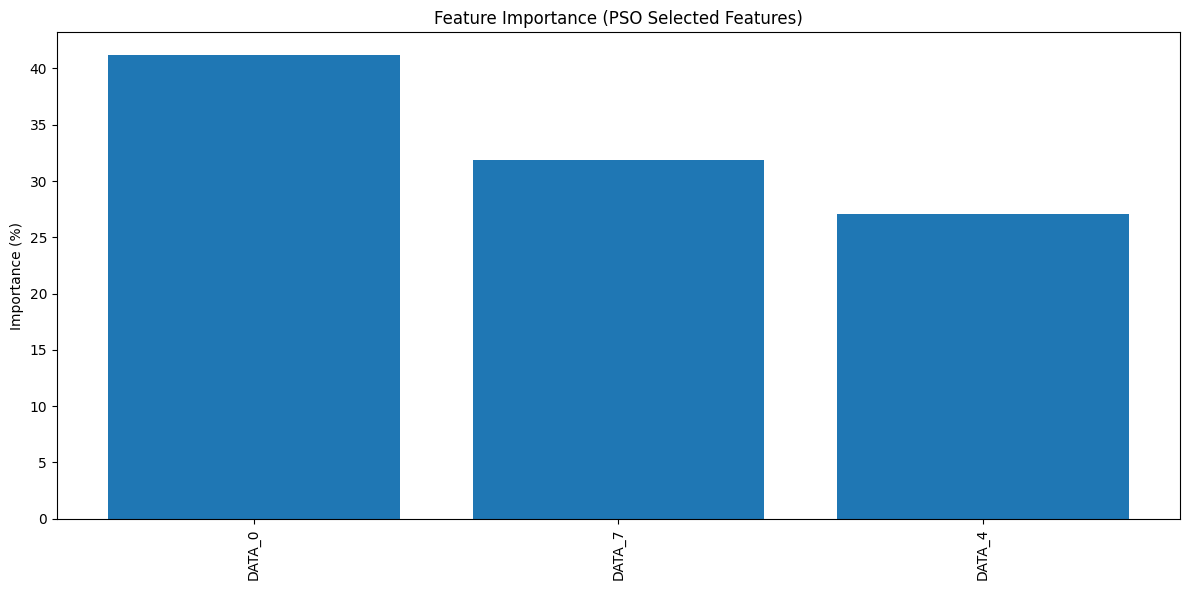

In [101]:
# FEATURE IMPORTANCE (PSO FEATURES)

print("\n FEATURE IMPORTANCE (PSO SELECTED FEATURES)")
print("=" * 45)

fi_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

fi_model.fit(X_train, y_train)

importances = fi_model.feature_importances_

selected_feature_names = np.array(feature_names)[final_mask.astype(bool)]

importance_percent = 100 * importances / importances.sum()

idx = np.argsort(importance_percent)[::-1]

sorted_features = selected_feature_names[idx]
sorted_importance = importance_percent[idx]

print("\n TOP FEATURE IMPORTANCE:")
for i in range(len(sorted_features)):
    print(f"{i+1:02d}. {sorted_features[i]} → {sorted_importance[i]:.2f}")


plot_dir = "/content/drive/MyDrive/CIC_IOV_2024/plots/PSO"
os.makedirs(plot_dir, exist_ok=True)

plt.figure(figsize=(12, 6))
plt.bar(sorted_features[:20], sorted_importance[:20])
plt.xticks(rotation=90)
plt.title("Feature Importance (PSO Selected Features)")
plt.ylabel("Importance (%)")
plt.tight_layout()

plt.savefig(os.path.join(plot_dir, "pso_feature_importance.png"), dpi=300, bbox_inches="tight")
plt.show()

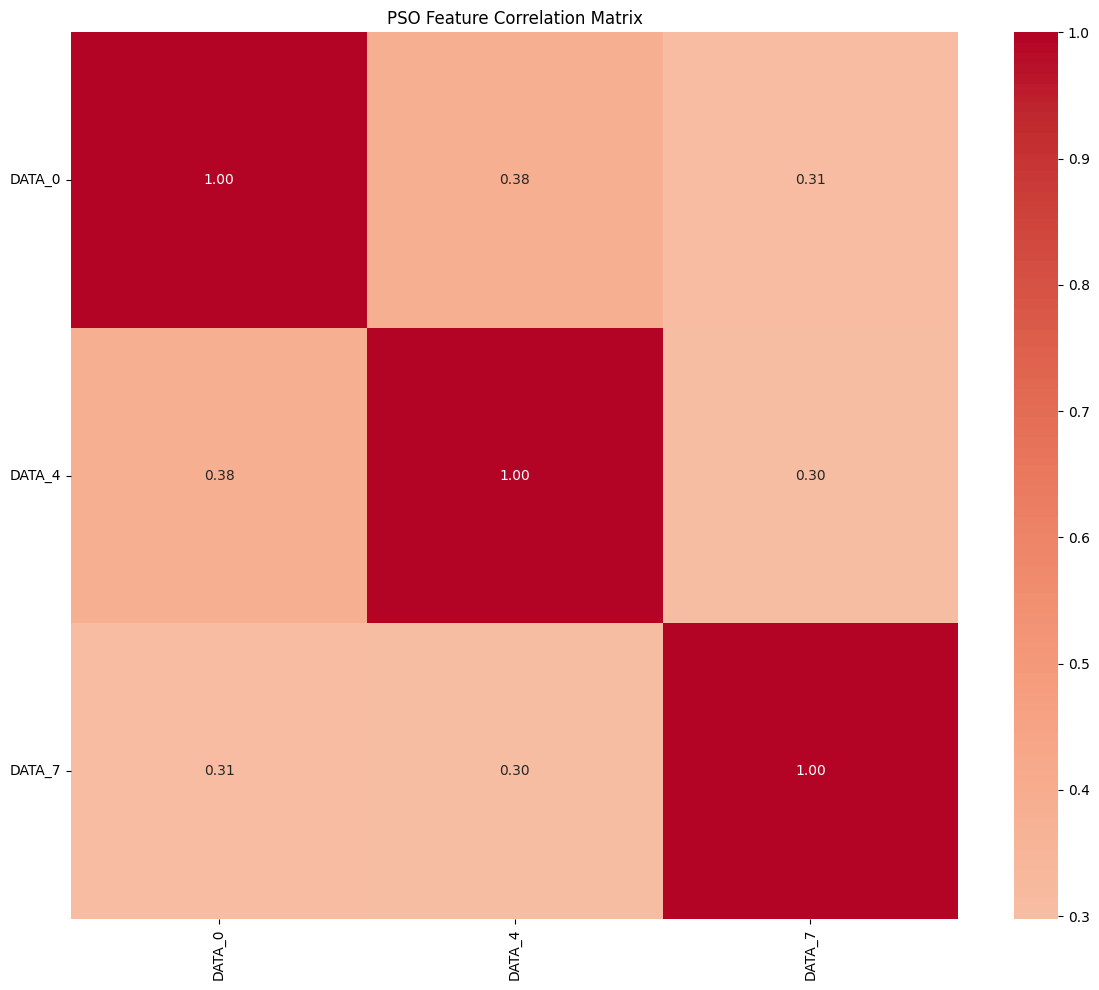

In [102]:
# HEATMAP - CORRELATION OF PSO FEATURES

pso_feature_names = np.array(feature_names)[final_mask.astype(bool)]
corr_matrix = np.corrcoef(X_train_selected.T)

plot_dir = "/content/drive/MyDrive/CIC_IOV_2024/plots/PSO"
os.makedirs(plot_dir, exist_ok=True)

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0,
    annot=True,
    fmt=".2f",
    xticklabels=pso_feature_names,
    yticklabels=pso_feature_names
)

plt.title("PSO Feature Correlation Matrix")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()

plt.savefig(os.path.join(plot_dir, "pso_feature_correlation_heatmap.png"), dpi=300, bbox_inches="tight")
plt.show()

# ***ML MODELING***

In [96]:
data_features = np.load(os.path.join(base_path, 'artifacts/final_features.npz'), allow_pickle=True)
final_features = data_features['final_features'].tolist()
final_mask = data_features['best_mask']

full_data = np.load(os.path.join(base_path, 'artifacts/full_split.npz'), allow_pickle=True)
X_train_scaled = full_data['X_train_scaled']
y_train_enc = full_data['y_train_enc']

# Apply feature mask
X_train_selected = X_train_scaled[:, final_mask.astype(bool)]

print(f" PSO Features: {len(final_features)}")
print(f" {final_features}")


# TRAIN / VAL / TEST SPLIT

X_temp, X_test, y_temp, y_test = train_test_split(
    X_train_selected,
    y_train_enc,
    test_size=0.15,
    stratify=y_train_enc,
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.1765,
    stratify=y_temp,
    random_state=42
)

print(f" Dataset splits:")
print(f"  Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")

np.savez_compressed(
    os.path.join(base_path, 'artifacts/data_split.npz'),
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test
)

print(" DATA SPLITS SAVED - artifacts/data_split.npz")

 PSO Features: 3
 ['DATA_0', 'DATA_4', 'DATA_7']
 Dataset splits:
  Train: (788573, 3) | Val: (169015, 3) | Test: (168987, 3)
 DATA SPLITS SAVED - artifacts/data_split.npz


In [103]:
# BASE PATHS
model_base_path = "/content/drive/MyDrive/CIC_IOV_2024/models"
plot_base_path = "/content/drive/MyDrive/CIC_IOV_2024/plots/ML plots"

os.makedirs(model_base_path, exist_ok=True)
os.makedirs(plot_base_path, exist_ok=True)

# MODELS
models = {
    'XGBoost': xgb.XGBClassifier(n_estimators=200, random_state=42, n_jobs=-1, eval_metric='mlogloss'),
    'LightGBM': lgb.LGBMClassifier(n_estimators=200, random_state=42, n_jobs=-1, verbose=-1),
    'CatBoost': CatBoostClassifier(n_estimators=200, random_state=42, verbose=False),
    'RandomForest': RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'ExtraTrees': ExtraTreesClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'DecisionTree': DecisionTreeClassifier(random_state=42, max_depth=15),
    'AdaBoost': AdaBoostClassifier(n_estimators=200, random_state=42)
}

results = {}
class_names = np.unique(y_train_enc)


# TRAIN LOOP

for name, model in models.items():

    print(f"\n TRAINING {name}...")

    model.fit(X_train, y_train)


    # PREDICTIONS

    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)
    test_pred = model.predict(X_test)


    # SAVE MODEL

    model_dir = os.path.join(model_base_path, name)
    os.makedirs(model_dir, exist_ok=True)

    joblib.dump(model, os.path.join(model_dir, f"{name}.pkl"))


    # SAVE PREDICTIONS

    np.save(os.path.join(model_dir, "train_pred.npy"), train_pred)
    np.save(os.path.join(model_dir, "val_pred.npy"), val_pred)
    np.save(os.path.join(model_dir, "test_pred.npy"), test_pred)

    np.save(os.path.join(model_dir, "y_train.npy"), y_train)
    np.save(os.path.join(model_dir, "y_val.npy"), y_val)
    np.save(os.path.join(model_dir, "y_test.npy"), y_test)


    # CONFUSION MATRIX

    cm = confusion_matrix(y_test, test_pred)

    cm_dir = os.path.join(plot_base_path, name)
    os.makedirs(cm_dir, exist_ok=True)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names)

    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()

    plt.savefig(os.path.join(cm_dir, "confusion_matrix.png"), dpi=300, bbox_inches="tight")
    plt.close()


    # METRICS

    model_results = {
        'Train_Accuracy': model.score(X_train, y_train),
        'Val_Accuracy': model.score(X_val, y_val),
        'Test_Accuracy': model.score(X_test, y_test),
        'Val_F1_macro': f1_score(y_val, val_pred, average='macro'),
        'Test_F1_macro': f1_score(y_test, test_pred, average='macro'),
        'Val_F1_weighted': f1_score(y_val, val_pred, average='weighted'),
        'Test_F1_weighted': f1_score(y_test, test_pred, average='weighted')
    }

    results[name] = model_results

    print(f"   Test F1: {model_results['Test_F1_weighted']:.4f}")


# SAVE METRICS

df_results = pd.DataFrame(results).T
df_results.to_csv("/content/drive/MyDrive/CIC_IOV_2024/model_results.csv")

print("\n COMPLETE RESULTS")
print(df_results.round(4).to_string())

print("\n SAVED SUCCESSFULLY")


 TRAINING XGBoost...
   Test F1: 0.9963

 TRAINING LightGBM...
   Test F1: 0.9963

 TRAINING CatBoost...
   Test F1: 0.9963

 TRAINING RandomForest...
   Test F1: 0.9963

 TRAINING ExtraTrees...
   Test F1: 0.9963

 TRAINING DecisionTree...
   Test F1: 0.9963

 TRAINING AdaBoost...
   Test F1: 0.8789

 COMPLETE RESULTS
              Train_Accuracy  Val_Accuracy  Test_Accuracy  Val_F1_macro  Test_F1_macro  Val_F1_weighted  Test_F1_weighted
XGBoost               0.9965        0.9964         0.9964        0.9740         0.9742           0.9963            0.9963
LightGBM              0.9965        0.9964         0.9964        0.9740         0.9742           0.9963            0.9963
CatBoost              0.9965        0.9964         0.9964        0.9740         0.9742           0.9963            0.9963
RandomForest          0.9965        0.9964         0.9964        0.9740         0.9742           0.9963            0.9963
ExtraTrees            0.9965        0.9964         0.9964        0.9

In [104]:
def check_duplicates(X_train, X_test):
    train_set = set(map(tuple, X_train))
    test_set = set(map(tuple, X_test))

    overlap = len(train_set.intersection(test_set))
    print("Duplicate rows in train-test:", overlap)

check_duplicates(X_train, X_test)

Duplicate rows in train-test: 161


In [105]:
from sklearn.feature_selection import mutual_info_classif
import numpy as np

mi = mutual_info_classif(X_train, y_train)

for i, v in enumerate(mi):
    print(feature_names[i], ":", v)

DATA_0 : 0.46817447143767854
DATA_1 : 0.4096129476114514
DATA_2 : 0.4332837707200001


In [107]:
from scipy.stats import ks_2samp

for i in range(X_train.shape[1]):
    stat, p = ks_2samp(X_train[:, i], X_test[:, i])
    print(feature_names[i], p)

DATA_0 0.9567967787140814
DATA_1 0.9921122790078861
DATA_2 0.9999978773936472


# ***SHAP***

In [26]:
import os
import numpy as np
import joblib
import shap
import lime.lime_tabular
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix

# PATHS
base_path = "/content/drive/MyDrive/CIC_IOV_2024"
artifacts_path = os.path.join(base_path, "artifacts")
models_path = os.path.join(base_path, "models")

In [27]:
# LOAD DATA
data = np.load(os.path.join(artifacts_path, "full_split.npz"), allow_pickle=True)

X_train = data["X_train_scaled"]
X_test = data["X_test_scaled"]
y_train = data["y_train_enc"]
y_test = data["y_test_enc"]
feature_names = data["feature_names"].tolist()
classes = data["classes"]


In [28]:

# LOAD FEATURE SELECTION
feat = np.load(os.path.join(artifacts_path, "final_features.npz"), allow_pickle=True)

mask = feat["best_mask"].astype(bool)

X_train_final = X_train[:, mask]
X_test_final = X_test[:, mask]

final_feature_names = np.array(feature_names)[mask]

In [29]:

# LOAD BEST MODEL
best_model_name = "RandomForest"
model = joblib.load(os.path.join(models_path, best_model_name, f"{best_model_name}.pkl"))

print(" Model Loaded:", best_model_name)
print(" Train shape:", X_train_final.shape)
print(" Test shape:", X_test_final.shape)

 Model Loaded: RandomForest
 Train shape: (1126575, 3)
 Test shape: (281644, 3)


DATA LOADED
Train: (1126575, 3)
Test: (281644, 3)
Features: 3

Best Model: RandomForest

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    244748
           1       1.00      1.00      1.00     14933
           2       1.00      1.00      1.00      1998
           3       0.92      1.00      0.96     10980
           4       1.00      0.80      0.89      4990
           5       1.00      1.00      1.00      3995

    accuracy                           1.00    281644
   macro avg       0.99      0.97      0.97    281644
weighted avg       1.00      1.00      1.00    281644

Accuracy: 0.996378406783031
F1 (weighted): 0.9962534620496504


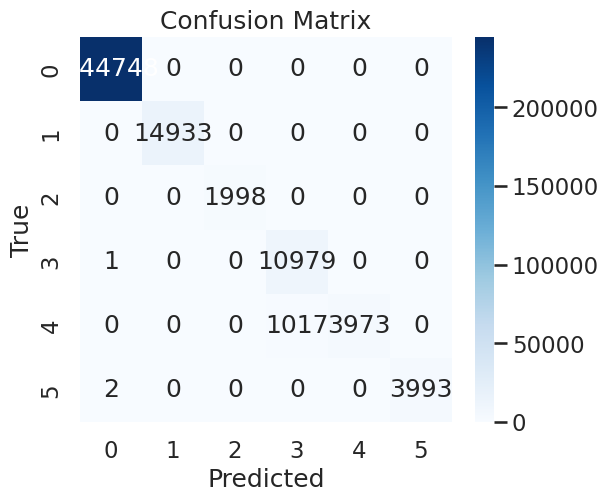


SHAP SHAPE CHECK
Background: (1000, 3)
X SHAP: (1000, 3)


 98%|===================| 5886/6000 [00:35<00:00]       


Final SHAP shape: (1000, 3, 6)

=== GLOBAL FEATURE IMPORTANCE ===
DATA_0 : 0.10848
DATA_4 : 0.10253
DATA_7 : 0.08822


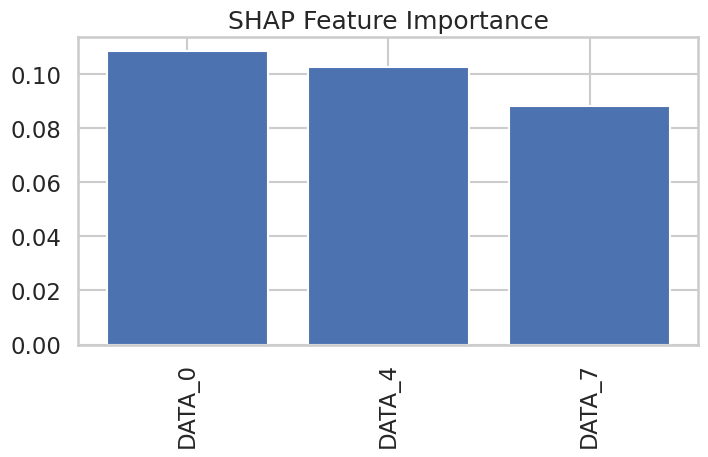

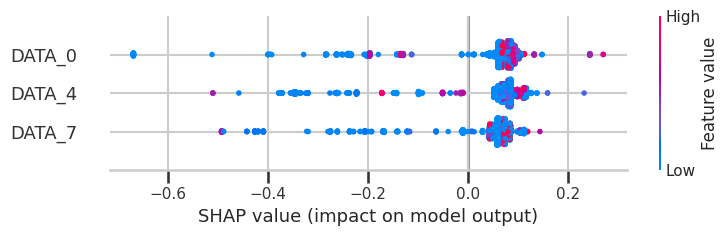

<Figure size 640x480 with 0 Axes>

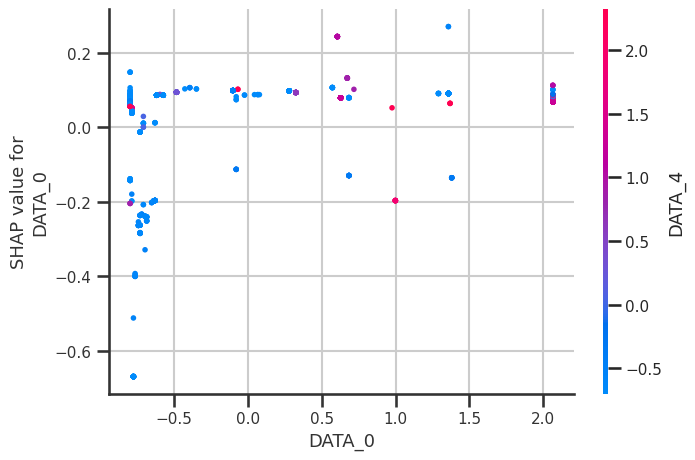

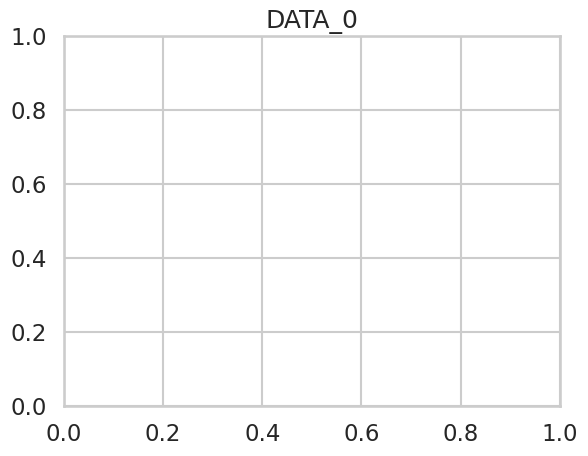

<Figure size 640x480 with 0 Axes>

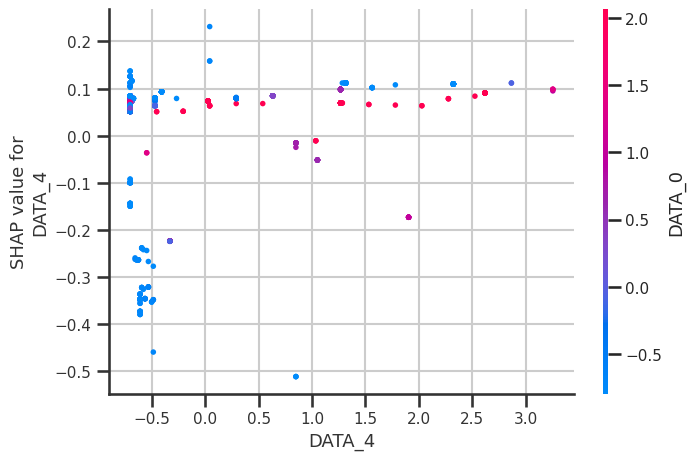

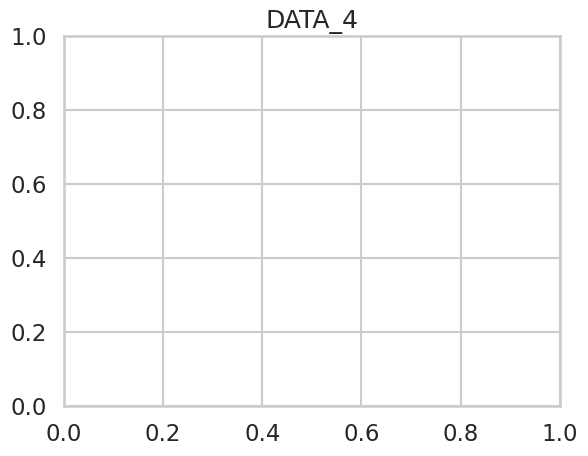

<Figure size 640x480 with 0 Axes>

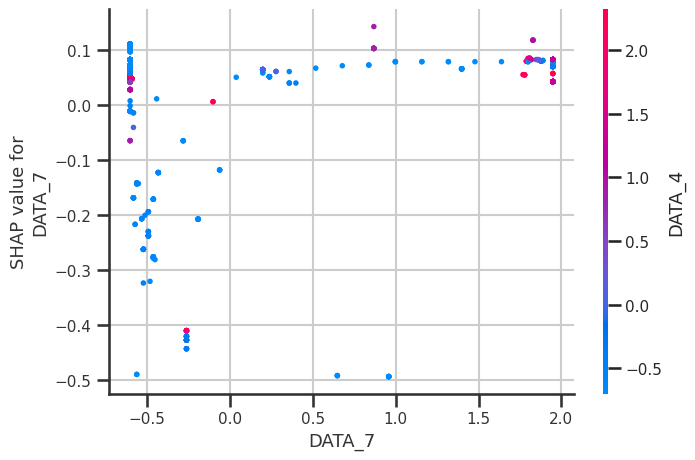

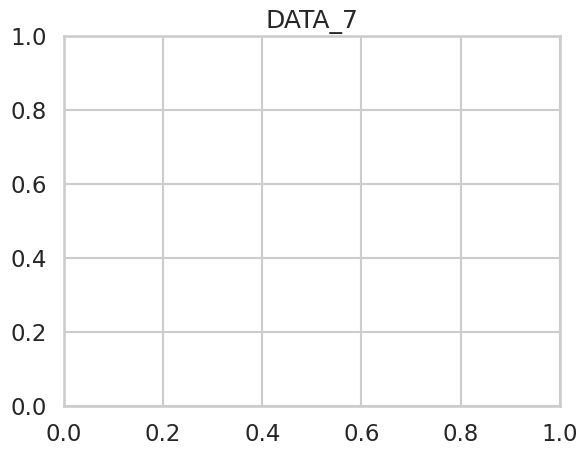


=== LOCAL SHAP EXPLANATIONS ===

Sample 0 | True: 0 | Pred: 0
  Feature      SHAP
1  DATA_4  0.084443
2  DATA_7  0.073432
0  DATA_0  0.062028


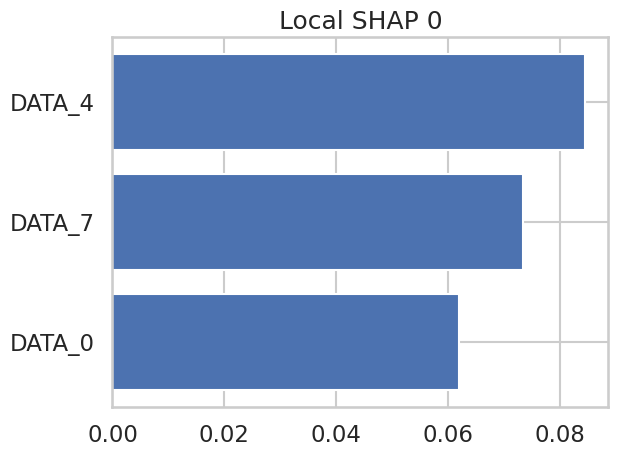


Sample 1 | True: 0 | Pred: 0
  Feature      SHAP
0  DATA_0  0.090296
1  DATA_4  0.070692
2  DATA_7  0.059021


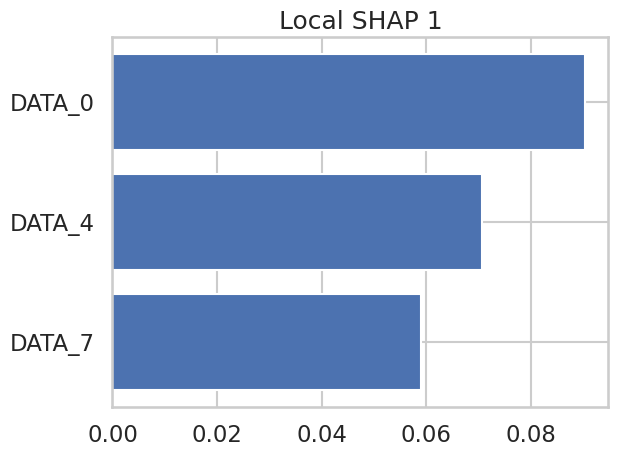


Sample 2 | True: 0 | Pred: 0
  Feature      SHAP
2  DATA_7  0.079320
0  DATA_0  0.077966
1  DATA_4  0.062723


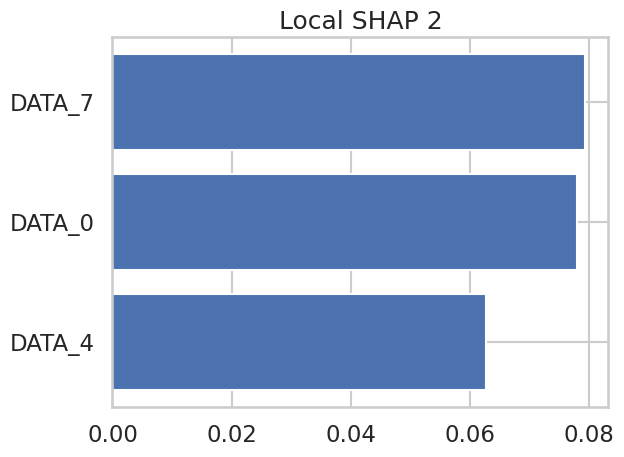


Sample 3 | True: 0 | Pred: 0
  Feature      SHAP
1  DATA_4  0.111837
0  DATA_0  0.059293
2  DATA_7  0.048878


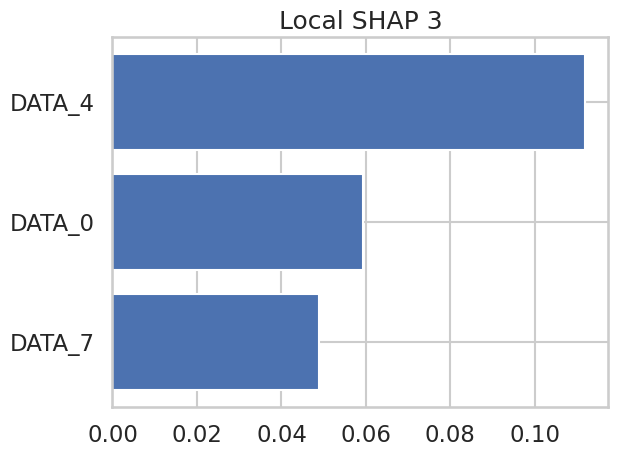


Sample 4 | True: 0 | Pred: 0
  Feature      SHAP
0  DATA_0  0.087961
2  DATA_7  0.080136
1  DATA_4  0.051911


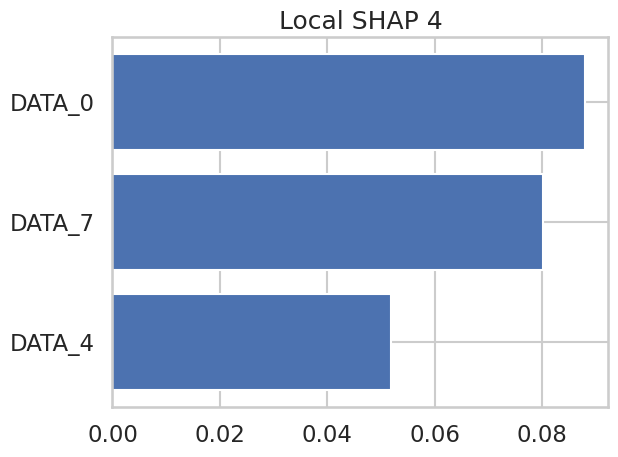

In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib

from lime.lime_tabular import LimeTabularExplainer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

np.random.seed(42)
sns.set_theme(style="whitegrid", context="talk")


base_path = "/content/drive/MyDrive/CIC_IOV_2024"

artifacts_dir = os.path.join(base_path, "artifacts")
models_dir = os.path.join(base_path, "models")

preproc = np.load(os.path.join(artifacts_dir, "full_split.npz"), allow_pickle=True)
features = np.load(os.path.join(artifacts_dir, "final_features.npz"), allow_pickle=True)

X_train_full = preproc["X_train_scaled"]
X_test_full = preproc["X_test_scaled"]
y_train = preproc["y_train_enc"]
y_test = preproc["y_test_enc"]

all_feature_names = preproc["feature_names"].tolist()

mask = features["best_mask"].astype(bool)

# SAFE FEATURE SELECTION
X_train_final = X_train_full[:, mask]
X_test_final = X_test_full[:, mask]

final_feature_names = np.array(all_feature_names)[mask].tolist()

classes_arr = preproc["classes"] if "classes" in preproc.files else np.unique(y_train)

print("DATA LOADED")
print("Train:", X_train_final.shape)
print("Test:", X_test_final.shape)
print("Features:", len(final_feature_names))

best_model_name = "RandomForest"
model = joblib.load(os.path.join(models_dir, best_model_name, f"{best_model_name}.pkl"))

print("\nBest Model:", best_model_name)

# PREDICTION + METRICS
y_pred = model.predict(X_test_final)

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred))

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 (weighted):", f1_score(y_test, y_pred, average="weighted"))

# CONFUSION MATRIX
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


shap_sample = min(1000, len(X_train_final))
bg_idx = np.random.choice(len(X_train_final), shap_sample, replace=False)
background = X_train_final[bg_idx]

test_sample = min(1000, len(X_test_final))
test_idx = np.random.choice(len(X_test_final), test_sample, replace=False)

X_shap = X_test_final[test_idx]
y_shap_true = y_test[test_idx]
y_shap_pred = y_pred[test_idx]

print("\nSHAP SHAPE CHECK")
print("Background:", background.shape)
print("X SHAP:", X_shap.shape)

# SHAP EXPLAINER
if best_model_name in ["RandomForest", "ExtraTrees", "DecisionTree", "XGBoost", "LightGBM", "CatBoost"]:
    explainer = shap.TreeExplainer(model, data=background)
    shap_values = explainer.shap_values(X_shap)
else:
    explainer = shap.Explainer(model, background)
    shap_values = explainer(X_shap)

# FIX SHAP FORMAT
def extract_shap(values):
    if isinstance(values, list):
        return values[0]
    if hasattr(values, "values"):
        return values.values
    return values

shap_matrix = extract_shap(shap_values)

print("\nFinal SHAP shape:", shap_matrix.shape)

# MULTI-CLASS FIX
if shap_matrix.ndim == 3:
    shap_matrix = shap_matrix[:, :, 0]

# GLOBAL IMPORTANCE
importance = np.mean(np.abs(shap_matrix), axis=0)

print("\n=== GLOBAL FEATURE IMPORTANCE ===")
for i in np.argsort(importance)[::-1]:
    print(f"{final_feature_names[i]} : {importance[i]:.5f}")

# BAR PLOT
plt.figure(figsize=(8, 4))
plt.bar(final_feature_names, importance)
plt.xticks(rotation=90)
plt.title("SHAP Feature Importance")
plt.show()

# SHAP SUMMARY PLOT

plt.figure()
shap.summary_plot(
    shap_matrix,
    X_shap,
    feature_names=final_feature_names
)

# DEPENDENCE PLOTS
for i, feat in enumerate(final_feature_names):
    plt.figure()
    shap.dependence_plot(i, shap_matrix, X_shap, feature_names=final_feature_names)
    plt.title(feat)
    plt.show()

# LOCAL EXPLANATIONS
print("\n=== LOCAL SHAP EXPLANATIONS ===")

for i in range(min(5, len(X_shap))):
    sv = shap_matrix[i]

    df_local = pd.DataFrame({
        "Feature": final_feature_names,
        "SHAP": sv
    }).sort_values("SHAP", key=np.abs, ascending=False)

    print(f"\nSample {i} | True: {y_shap_true[i]} | Pred: {y_shap_pred[i]}")
    print(df_local)

    plt.figure()
    plt.barh(df_local["Feature"][:10][::-1], df_local["SHAP"][:10][::-1])
    plt.title(f"Local SHAP {i}")
    plt.show()


In [6]:
# FULL FEATURE DATA
X_train_full = preproc["X_train_scaled"]
X_test_full = preproc["X_test_scaled"]

full_feature_names = preproc["feature_names"].tolist()

print("FULL FEATURES:", len(full_feature_names))

# SAMPLE
bg_idx = np.random.choice(len(X_train_full), min(1000, len(X_train_full)), replace=False)
background_full = X_train_full[bg_idx]

test_idx = np.random.choice(len(X_test_full), min(1000, len(X_test_full)), replace=False)
X_full_shap = X_test_full[test_idx]

# EXPLAINER
explainer_full = shap.TreeExplainer(model, data=background_full)
shap_values_full = explainer_full.shap_values(X_full_shap)

# FIX FORMAT
if isinstance(shap_values_full, list):
    shap_full = shap_values_full[0]
elif hasattr(shap_values_full, "values"):
    shap_full = shap_values_full.values
else:
    shap_full = shap_values_full

if shap_full.ndim == 3:
    shap_full = shap_full[:, :, 0]

# IMPORTANCE
imp_full = np.mean(np.abs(shap_full), axis=0)

full_df = pd.DataFrame({
    "Feature": full_feature_names,
    "SHAP_FULL": imp_full
}).sort_values("SHAP_FULL", ascending=False)

print("\n=== FULL FEATURE IMPORTANCE ===")
print(full_df.head(10))

FULL FEATURES: 8


 97%|=================== | 5791/6000 [00:44<00:01]       


=== FULL FEATURE IMPORTANCE ===
  Feature  SHAP_FULL
2  DATA_2   0.083946
1  DATA_1   0.067818
0  DATA_0   0.059327
3  DATA_3   0.000000
4  DATA_4   0.000000
5  DATA_5   0.000000
6  DATA_6   0.000000
7  DATA_7   0.000000


In [7]:
# PSO FEATURES
mask = features["best_mask"].astype(bool)

X_train_pso = X_train_full[:, mask]
X_test_pso = X_test_full[:, mask]

pso_feature_names = np.array(full_feature_names)[mask].tolist()

print("PSO FEATURES:", len(pso_feature_names))

# SAMPLE
bg_idx = np.random.choice(len(X_train_pso), min(1000, len(X_train_pso)), replace=False)
background_pso = X_train_pso[bg_idx]

test_idx = np.random.choice(len(X_test_pso), min(1000, len(X_test_pso)), replace=False)
X_pso_shap = X_test_pso[test_idx]

# EXPLAINER
explainer_pso = shap.TreeExplainer(model, data=background_pso)
shap_values_pso = explainer_pso.shap_values(X_pso_shap)

# FIX FORMAT
if isinstance(shap_values_pso, list):
    shap_pso = shap_values_pso[0]
elif hasattr(shap_values_pso, "values"):
    shap_pso = shap_values_pso.values
else:
    shap_pso = shap_values_pso

if shap_pso.ndim == 3:
    shap_pso = shap_pso[:, :, 0]

# IMPORTANCE
imp_pso = np.mean(np.abs(shap_pso), axis=0)

pso_df = pd.DataFrame({
    "Feature": pso_feature_names,
    "SHAP_PSO": imp_pso
}).sort_values("SHAP_PSO", ascending=False)

print("\n=== PSO FEATURE IMPORTANCE ===")
print(pso_df)

PSO FEATURES: 3


 99%|===================| 5939/6000 [00:30<00:00]       


=== PSO FEATURE IMPORTANCE ===
  Feature  SHAP_PSO
0  DATA_0  0.092807
1  DATA_4  0.073073
2  DATA_7  0.059747


In [8]:
# MERGE COMPARISON
compare_df = full_df.merge(pso_df, on="Feature", how="left").fillna(0)

compare_df["Selected_by_PSO"] = compare_df["SHAP_PSO"] > 0

print("\n=== COMPARISON ===")
print(compare_df.head(15))


=== COMPARISON ===
  Feature  SHAP_FULL  SHAP_PSO  Selected_by_PSO
0  DATA_2   0.083946  0.000000            False
1  DATA_1   0.067818  0.000000            False
2  DATA_0   0.059327  0.092807             True
3  DATA_3   0.000000  0.000000            False
4  DATA_4   0.000000  0.073073             True
5  DATA_5   0.000000  0.000000            False
6  DATA_6   0.000000  0.000000            False
7  DATA_7   0.000000  0.059747             True


In [51]:
from sklearn.metrics import accuracy_score, f1_score, classification_report
import os
import numpy as np
from sklearn.ensemble import RandomForestClassifier


if 'base_path' not in locals():
    base_path = "/content/drive/MyDrive/CIC_IOV_2024"


preproc_data = np.load(os.path.join(base_path, "artifacts/full_split.npz"), allow_pickle=True)
X_train_full = preproc_data["X_train_scaled"]
y_train_full_labels = preproc_data["y_train_enc"]
X_test_full = preproc_data["X_test_scaled"]
y_test_full_labels = preproc_data["y_test_enc"]


print("\nTRAINING FULL MODEL (RandomForest) on all features...")
full_model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
full_model.fit(X_train_full, y_train_full_labels)
print("FULL MODEL trained successfully.")

# Make predictions with the full model
y_pred_full = full_model.predict(X_test_full)

acc_full = accuracy_score(y_test_full_labels, y_pred_full)
f1_full = f1_score(y_test_full_labels, y_pred_full, average="weighted")

print("\n=== FULL MODEL EVALUATION ===")
print(f"Accuracy: {acc_full:.4f}")
print(f"F1 (weighted): {f1_full:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_full_labels, y_pred_full))


TRAINING FULL MODEL (RandomForest) on all features...
FULL MODEL trained successfully.

=== FULL MODEL EVALUATION ===
Accuracy: 0.9964
F1 (weighted): 0.9963

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    244748
           1       1.00      1.00      1.00     14933
           2       1.00      1.00      1.00      1998
           3       0.92      1.00      0.96     10980
           4       1.00      0.80      0.89      4990
           5       1.00      1.00      1.00      3995

    accuracy                           1.00    281644
   macro avg       0.99      0.97      0.97    281644
weighted avg       1.00      1.00      1.00    281644



In [53]:
# PSO MODEL EVALUATION

import os
import numpy as np
import joblib
from sklearn.metrics import accuracy_score, f1_score, classification_report

if 'base_path' not in locals():
    base_path = "/content/drive/MyDrive/CIC_IOV_2024"


data_split = np.load(os.path.join(base_path, 'artifacts/data_split.npz'), allow_pickle=True)
X_test_pso = data_split['X_test']
y_test = data_split['y_test']


model_name = "RandomForest"
model_path = os.path.join(base_path, "models", model_name, f"{model_name}.pkl")
pso_model = joblib.load(model_path)

print(f"Loaded model '{model_name}' as pso_model.")

y_pred_pso = pso_model.predict(X_test_pso)

acc_pso = accuracy_score(y_test, y_pred_pso)
f1_pso = f1_score(y_test, y_pred_pso, average="weighted")

print("\n=== PSO MODEL (RandomForest on selected features) ===")
print("Accuracy:", round(acc_pso, 4))
print("F1 (weighted):", round(f1_pso, 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_pso))

Loaded model 'RandomForest' as pso_model.

=== PSO MODEL (RandomForest on selected features) ===
Accuracy: 0.9964
F1 (weighted): 0.9963

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    146849
           1       1.00      1.00      1.00      8960
           2       1.00      1.00      1.00      1199
           3       0.92      1.00      0.96      6588
           4       1.00      0.80      0.89      2994
           5       1.00      1.00      1.00      2397

    accuracy                           1.00    168987
   macro avg       0.99      0.97      0.97    168987
weighted avg       1.00      1.00      1.00    168987



In [54]:
print("\n=== COMPARISON ===")
print(f"Accuracy → FULL: {acc_full:.4f} | PSO: {acc_pso:.4f}")
print(f"F1 Score → FULL: {f1_full:.4f} | PSO: {f1_pso:.4f}")


=== COMPARISON ===
Accuracy → FULL: 0.9964 | PSO: 0.9964
F1 Score → FULL: 0.9963 | PSO: 0.9963


In [57]:
from sklearn.model_selection import cross_val_score

cv_full = cross_val_score(full_model, X_train_full, y_train_full_labels, cv=5, scoring="f1_weighted")
cv_pso = cross_val_score(pso_model, data_split['X_train'], data_split['y_train'], cv=5, scoring="f1_weighted")

print("\n=== CROSS-VALIDATION ===")
print("FULL mean F1:", cv_full.mean())
print("PSO mean F1:", cv_pso.mean())


=== CROSS-VALIDATION ===
FULL mean F1: 0.9963784031531986
PSO mean F1: 0.9963554881884479


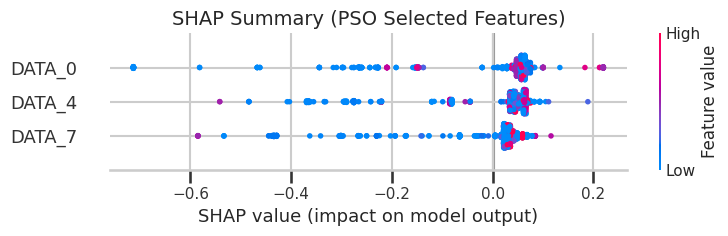

In [10]:
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_pso,
    X_pso_shap,
    feature_names=pso_feature_names,
    max_display=len(pso_feature_names),
    show=False
)
plt.title("SHAP Summary (PSO Selected Features)", fontsize=14)
plt.tight_layout()
plt.show()

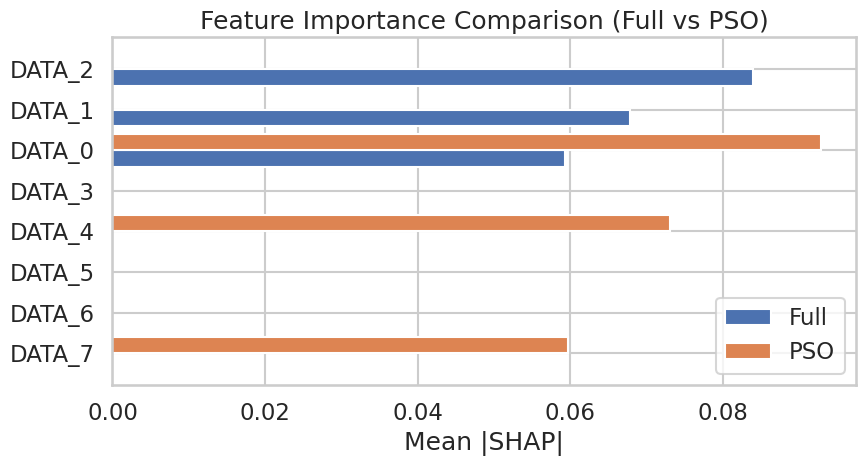

In [12]:
plot_df = compare_df.head(10).iloc[::-1]

x = np.arange(len(plot_df))

plt.figure(figsize=(9, 5))
plt.barh(x - 0.2, plot_df["SHAP_FULL"], height=0.4, label="Full")
plt.barh(x + 0.2, plot_df["SHAP_PSO"], height=0.4, label="PSO")

plt.yticks(x, plot_df["Feature"])
plt.xlabel("Mean |SHAP|")
plt.title("Feature Importance Comparison (Full vs PSO)")
plt.legend()
plt.tight_layout()
plt.show()

Selected Features: ['DATA_0', 'DATA_4', 'DATA_7']
Train shape: (1126575, 3)
Test shape: (281644, 3)

Model: RandomForest

=== METRICS ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    244748
           1       1.00      1.00      1.00     14933
           2       1.00      1.00      1.00      1998
           3       0.92      1.00      0.96     10980
           4       1.00      0.80      0.89      4990
           5       1.00      1.00      1.00      3995

    accuracy                           1.00    281644
   macro avg       0.99      0.97      0.97    281644
weighted avg       1.00      1.00      1.00    281644

Accuracy: 0.996378406783031
F1 (weighted): 0.9962534620496504


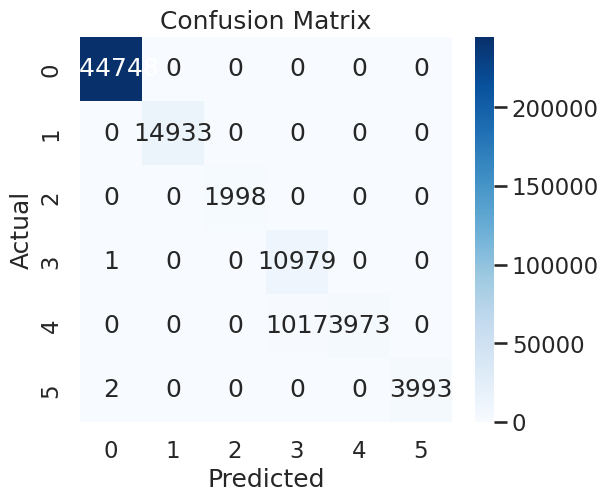


SHAP Input: (1000, 3)


 98%|===================| 5861/6000 [00:31<00:00]       

Final SHAP shape: (1000, 3)

=== GLOBAL FEATURE IMPORTANCE ===
  Feature  Importance
0  DATA_0    0.108481
1  DATA_4    0.102532
2  DATA_7    0.088220


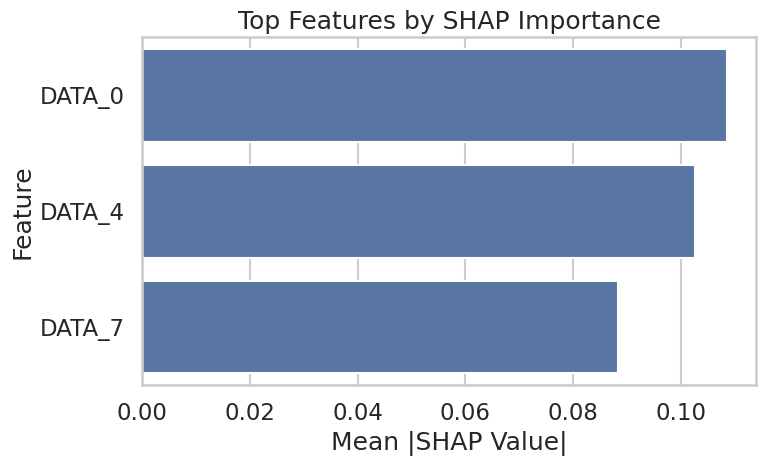

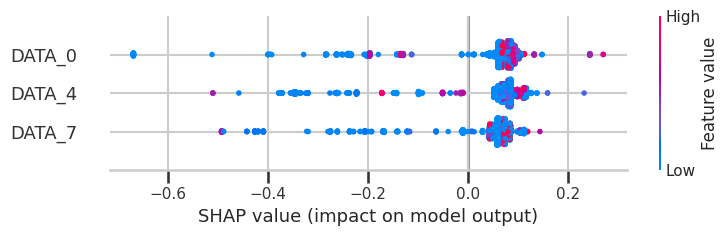


=== FEATURE EFFECTS ===


<Figure size 640x480 with 0 Axes>

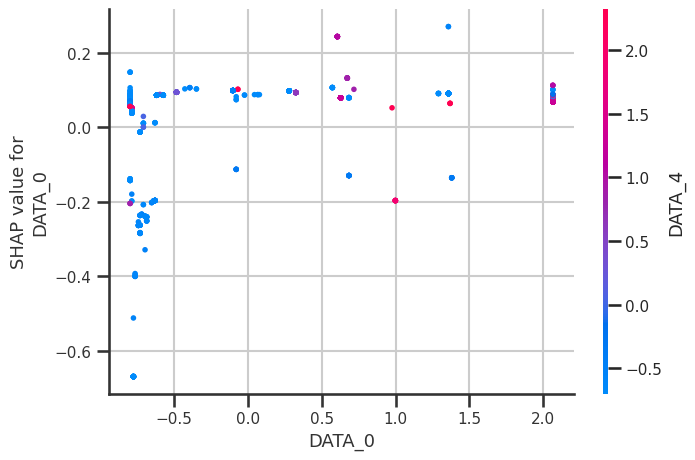

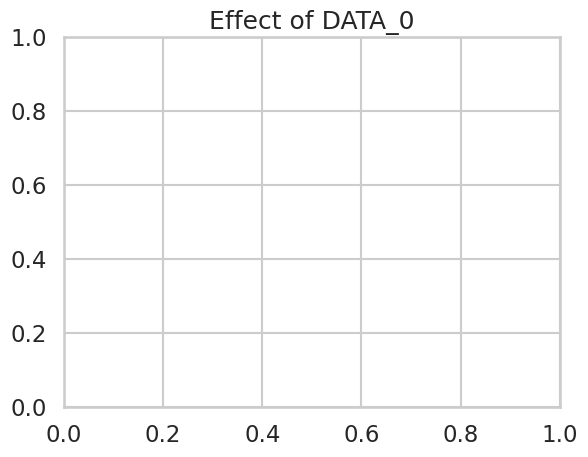

<Figure size 640x480 with 0 Axes>

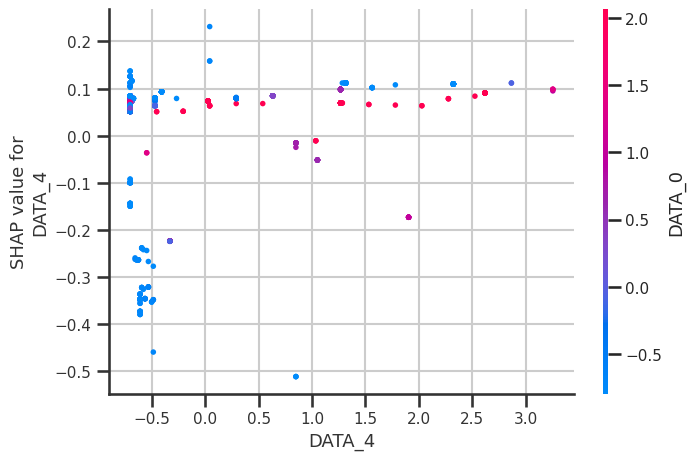

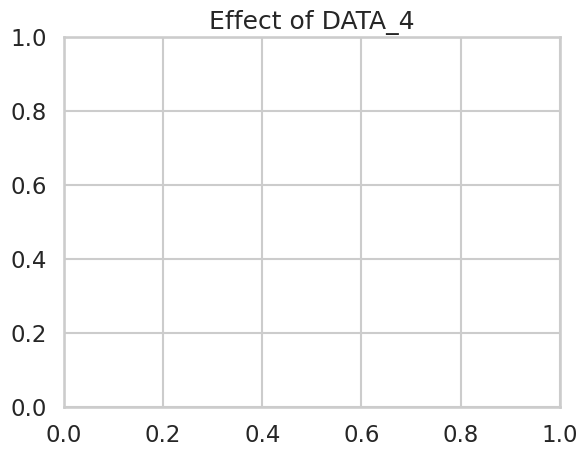

<Figure size 640x480 with 0 Axes>

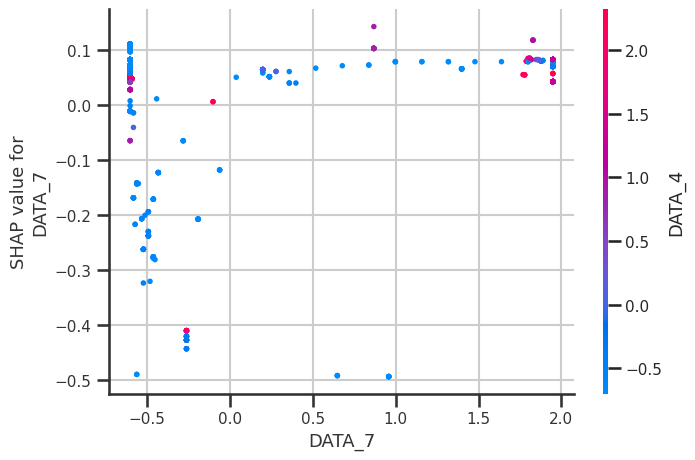

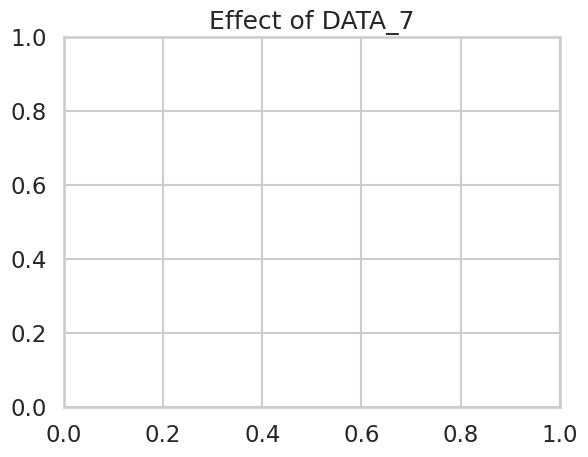


=== LOCAL EXPLANATIONS ===

Sample 0
True: 0 Pred: 0
  Feature  Contribution
1  DATA_4      0.084443
2  DATA_7      0.073432
0  DATA_0      0.062028


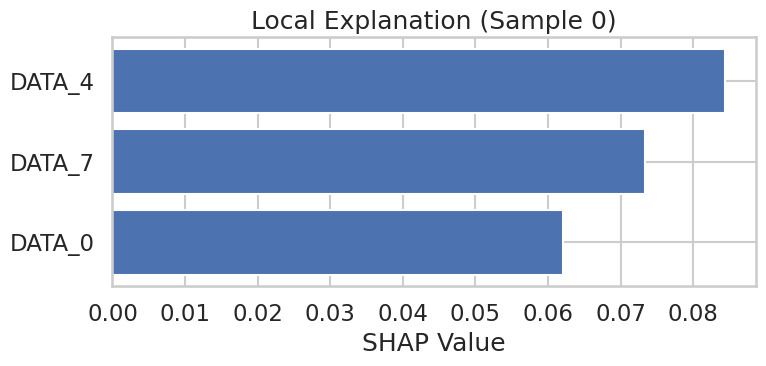

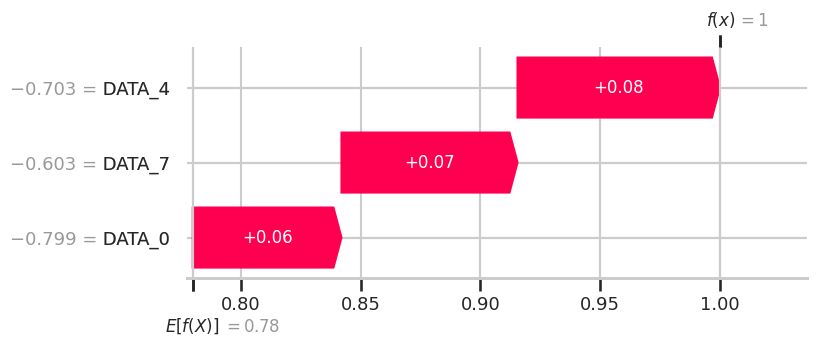


Sample 1
True: 0 Pred: 0
  Feature  Contribution
0  DATA_0      0.090296
1  DATA_4      0.070692
2  DATA_7      0.059021


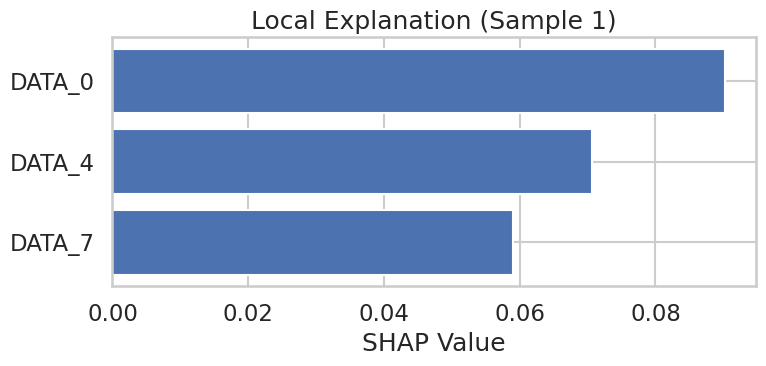

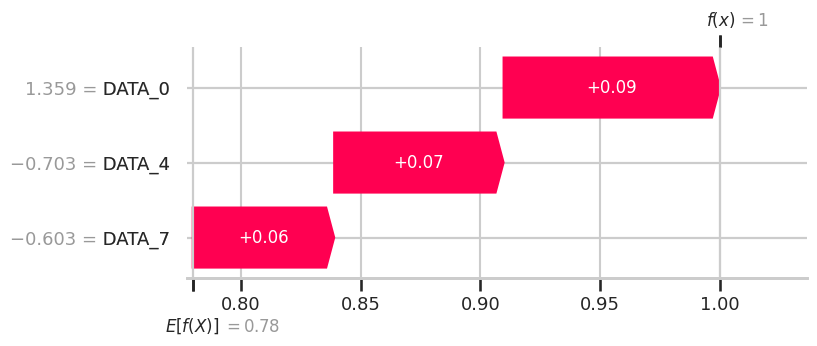


Sample 2
True: 0 Pred: 0
  Feature  Contribution
2  DATA_7      0.079320
0  DATA_0      0.077966
1  DATA_4      0.062723


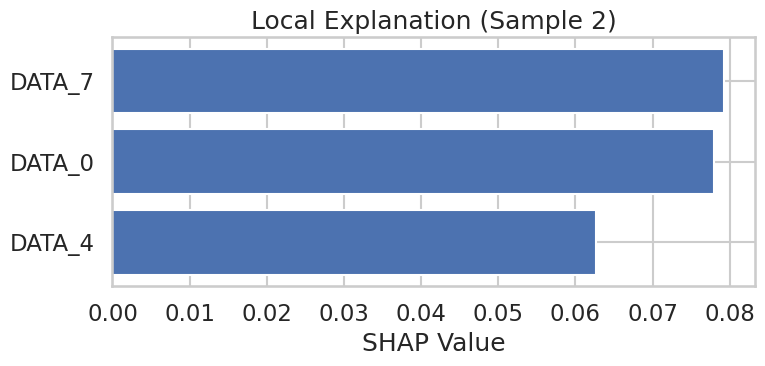

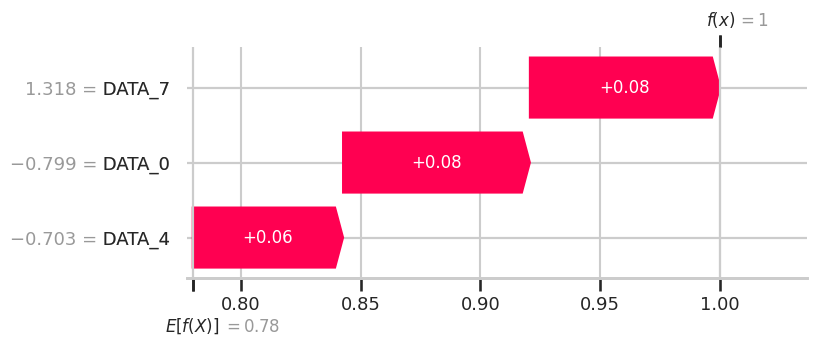


Sample 3
True: 0 Pred: 0
  Feature  Contribution
1  DATA_4      0.111837
0  DATA_0      0.059293
2  DATA_7      0.048878


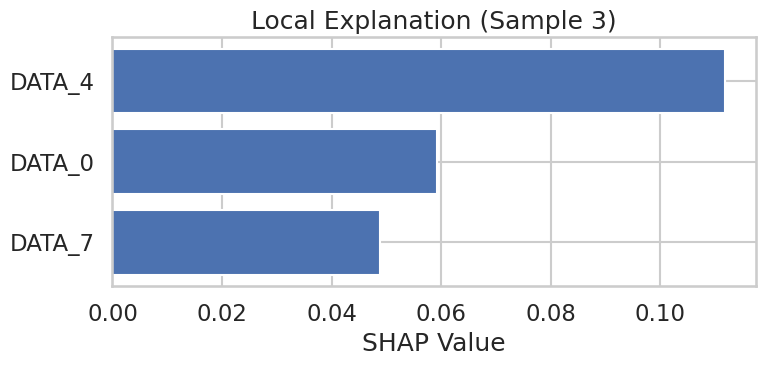

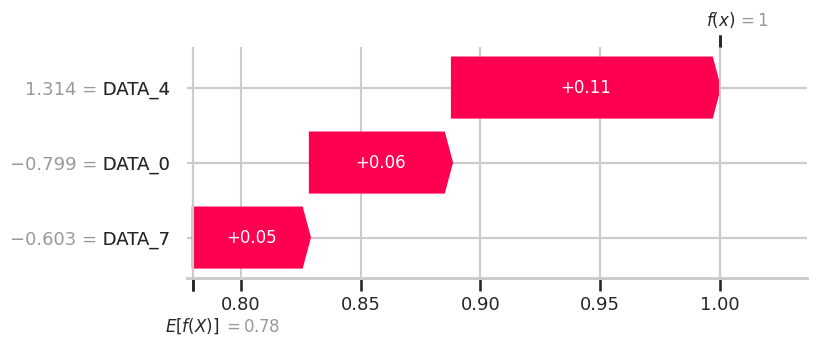


Sample 4
True: 0 Pred: 0
  Feature  Contribution
0  DATA_0      0.087961
2  DATA_7      0.080136
1  DATA_4      0.051911


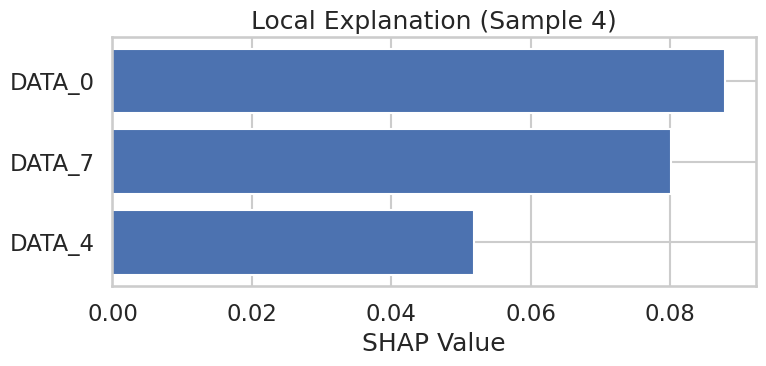

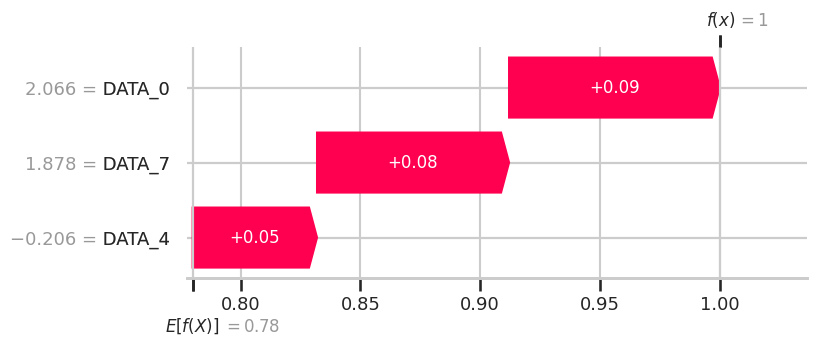

In [13]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score


np.random.seed(42)
sns.set_style("whitegrid")

BASE_DIR = "/content/drive/MyDrive/CIC_IOV_2024"
artifacts_dir = os.path.join(BASE_DIR, "artifacts")
models_dir = os.path.join(BASE_DIR, "models")

preproc = np.load(os.path.join(artifacts_dir, "full_split.npz"), allow_pickle=True)
features = np.load(os.path.join(artifacts_dir, "final_features.npz"), allow_pickle=True)

X_train_full = preproc["X_train_scaled"]
X_test_full = preproc["X_test_scaled"]
y_train = preproc["y_train_enc"]
y_test = preproc["y_test_enc"]

all_feature_names = preproc["feature_names"].tolist()

# FEATURE SELECTION (PSO)
mask = features["best_mask"].astype(bool)

X_train = X_train_full[:, mask]
X_test = X_test_full[:, mask]

feature_names = np.array(all_feature_names)[mask].tolist()

print("Selected Features:", feature_names)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


best_model_name = "RandomForest"
model = joblib.load(os.path.join(models_dir, best_model_name, f"{best_model_name}.pkl"))

print("\nModel:", best_model_name)

# PREDICTIONS
y_pred = model.predict(X_test)

print("\n=== METRICS ===")
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 (weighted):", f1_score(y_test, y_pred, average="weighted"))

# CONFUSION MATRIX
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

bg_size = min(1000, len(X_train))
test_size = min(1000, len(X_test))

bg_idx = np.random.choice(len(X_train), bg_size, replace=False)
test_idx = np.random.choice(len(X_test), test_size, replace=False)

background = X_train[bg_idx]
X_shap = X_test[test_idx]
y_shap = y_test[test_idx]
y_pred_shap = y_pred[test_idx]

print("\nSHAP Input:", X_shap.shape)


# SHAP EXPLAINER

explainer = shap.TreeExplainer(model, data=background)
shap_values = explainer.shap_values(X_shap)


# HANDLE MULTI-CLASS

if isinstance(shap_values, list):
    shap_matrix = shap_values[0]
elif hasattr(shap_values, "values"):
    shap_matrix = shap_values.values
else:
    shap_matrix = shap_values

if shap_matrix.ndim == 3:
    shap_matrix = shap_matrix[:, :, 0]

print("Final SHAP shape:", shap_matrix.shape)


# GLOBAL IMPORTANCE

importance = np.mean(np.abs(shap_matrix), axis=0)

shap_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
}).sort_values("Importance", ascending=False)

print("\n=== GLOBAL FEATURE IMPORTANCE ===")
print(shap_df)

# BAR PLOT
plt.figure(figsize=(8, 5))
sns.barplot(
    data=shap_df.head(10),
    x="Importance",
    y="Feature"
)
plt.title("Top Features by SHAP Importance")
plt.xlabel("Mean |SHAP Value|")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


# SUMMARY PLOT

plt.figure()
shap.summary_plot(
    shap_matrix,
    X_shap,
    feature_names=feature_names,
    max_display=len(feature_names)
)


# DEPENDENCE PLOTS (INTERACTIONS)

print("\n=== FEATURE EFFECTS ===")
for i, feat in enumerate(feature_names):
    plt.figure()
    shap.dependence_plot(
        i,
        shap_matrix,
        X_shap,
        feature_names=feature_names
    )
    plt.title(f"Effect of {feat}")
    plt.show()


# LOCAL EXPLANATIONS

print("\n=== LOCAL EXPLANATIONS ===")

for i in range(min(5, len(X_shap))):
    sv = shap_matrix[i]

    local_df = pd.DataFrame({
        "Feature": feature_names,
        "Contribution": sv
    }).sort_values("Contribution", key=np.abs, ascending=False)

    print(f"\nSample {i}")
    print("True:", y_shap[i], "Pred:", y_pred_shap[i])
    print(local_df)

    # BAR PLOT
    plt.figure(figsize=(8, 4))
    top = local_df.head(10).iloc[::-1]
    plt.barh(top["Feature"], top["Contribution"])
    plt.title(f"Local Explanation (Sample {i})")
    plt.xlabel("SHAP Value")
    plt.tight_layout()
    plt.show()

    try:
        base_val = explainer.expected_value
        if isinstance(base_val, (list, np.ndarray)):
            base_val = base_val[0]

        exp = shap.Explanation(
            values=sv,
            base_values=base_val,
            data=X_shap[i],
            feature_names=feature_names
        )

        plt.figure()
        shap.plots.waterfall(exp)
        plt.show()
    except:
        pass

In [14]:
import os
import numpy as np
import pandas as pd
import shap
import joblib

BASE_DIR = "/content/drive/MyDrive/CIC_IOV_2024"

preproc = np.load(os.path.join(BASE_DIR, "artifacts/full_split.npz"), allow_pickle=True)
features = np.load(os.path.join(BASE_DIR, "artifacts/final_features.npz"), allow_pickle=True)

X_train_full = preproc["X_train_scaled"]
X_test_full = preproc["X_test_scaled"]
y_train = preproc["y_train_enc"]
y_test = preproc["y_test_enc"]

feature_names_all = preproc["feature_names"].tolist()

mask = features["best_mask"].astype(bool)

X_train = X_train_full[:, mask]
X_test = X_test_full[:, mask]

feature_names = np.array(feature_names_all)[mask].tolist()

model = joblib.load(os.path.join(BASE_DIR, "models/RandomForest/RandomForest.pkl"))

print("Loaded")
print("Train:", X_train.shape)
print("Test:", X_test.shape)
print("Features:", feature_names)

Loaded
Train: (1126575, 3)
Test: (281644, 3)
Features: ['DATA_0', 'DATA_4', 'DATA_7']


In [15]:
np.random.seed(42)

bg_idx = np.random.choice(len(X_train), min(1000, len(X_train)), replace=False)
test_idx = np.random.choice(len(X_test), min(1000, len(X_test)), replace=False)

background = X_train[bg_idx]
X_shap = X_test[test_idx]

print("SHAP Input:", X_shap.shape)

SHAP Input: (1000, 3)


In [16]:
explainer = shap.TreeExplainer(model, data=background)
shap_values = explainer.shap_values(X_shap)

if isinstance(shap_values, list):
    shap_matrix = shap_values[0]
elif hasattr(shap_values, "values"):
    shap_matrix = shap_values.values
else:
    shap_matrix = shap_values

if shap_matrix.ndim == 3:
    shap_matrix = shap_matrix[:, :, 0]

print("Final SHAP shape:", shap_matrix.shape)

 97%|=================== | 5839/6000 [00:38<00:01]       

Final SHAP shape: (1000, 3)


In [17]:
importance = np.mean(np.abs(shap_matrix), axis=0)

shap_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
}).sort_values("Importance", ascending=False)

print(shap_df)

  Feature  Importance
0  DATA_0    0.108481
1  DATA_4    0.102532
2  DATA_7    0.088220


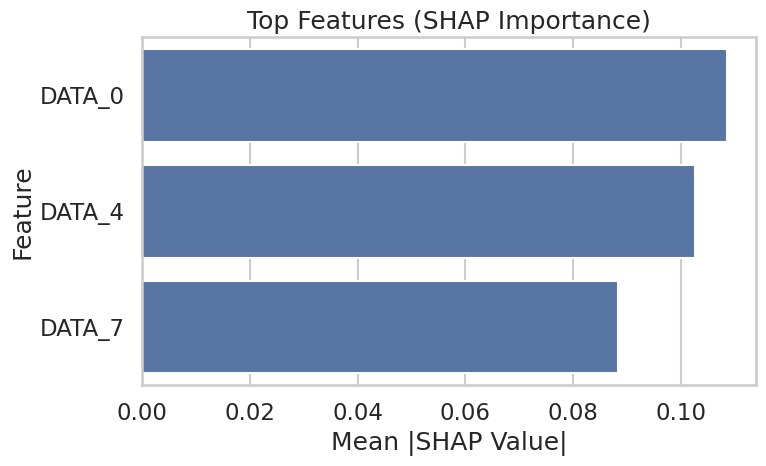

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.barplot(data=shap_df.head(10), x="Importance", y="Feature")
plt.title("Top Features (SHAP Importance)")
plt.xlabel("Mean |SHAP Value|")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

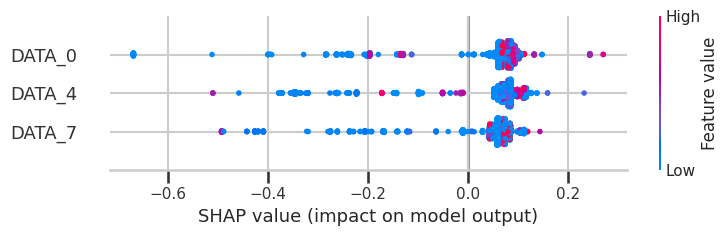

In [19]:
shap.summary_plot(
    shap_matrix,
    X_shap,
    feature_names=feature_names
)

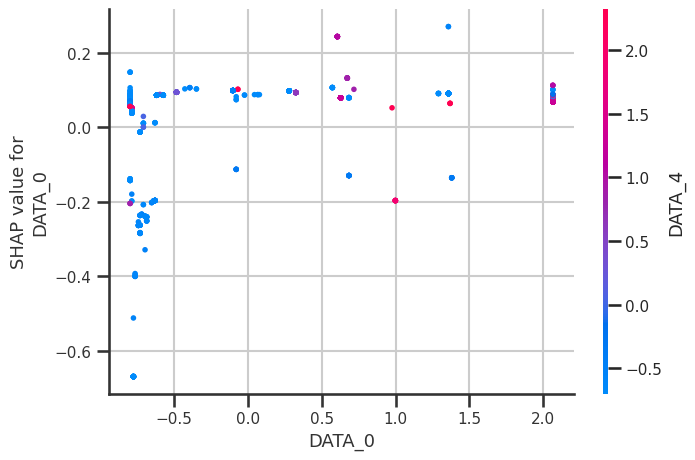

In [20]:
feat_index = 0

shap.dependence_plot(
    feat_index,
    shap_matrix,
    X_shap,
    feature_names=feature_names
)

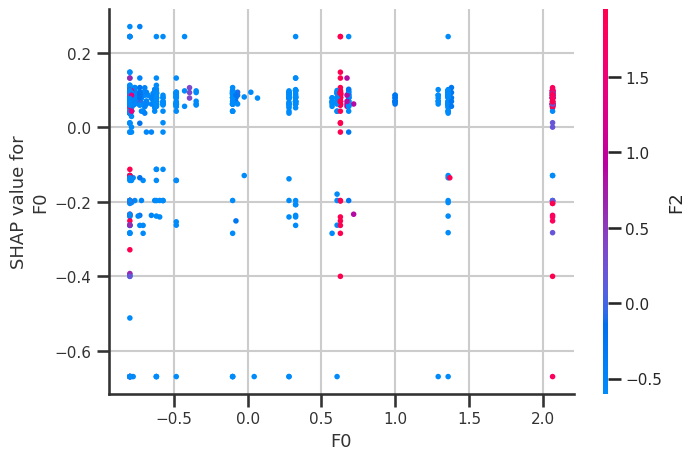

In [48]:
feat_index = 0

shap.dependence_plot(
    feat_index,
    shap_matrix,
    X_shap,
    feature_names=feature_names
)

In [21]:
i = 0

sv = shap_matrix[i]

local_df = pd.DataFrame({
    "Feature": feature_names,
    "SHAP": sv
}).sort_values("SHAP", key=np.abs, ascending=False)

print("True:", y_test[test_idx][i])
print(local_df)

True: 0
  Feature      SHAP
1  DATA_4  0.084443
2  DATA_7  0.073432
0  DATA_0  0.062028


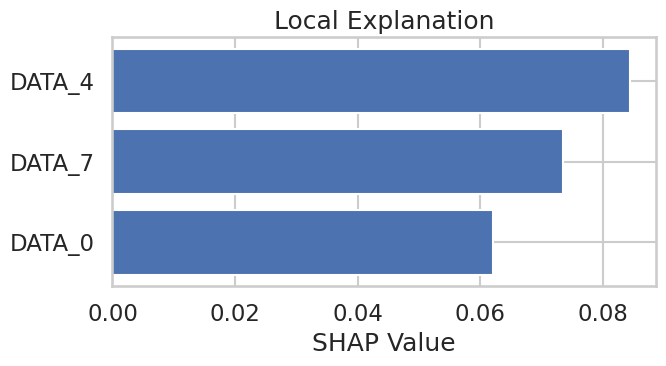

In [22]:
top = local_df.head(10).iloc[::-1]

plt.figure(figsize=(7, 4))
plt.barh(top["Feature"], top["SHAP"])
plt.title("Local Explanation")
plt.xlabel("SHAP Value")
plt.tight_layout()
plt.show()

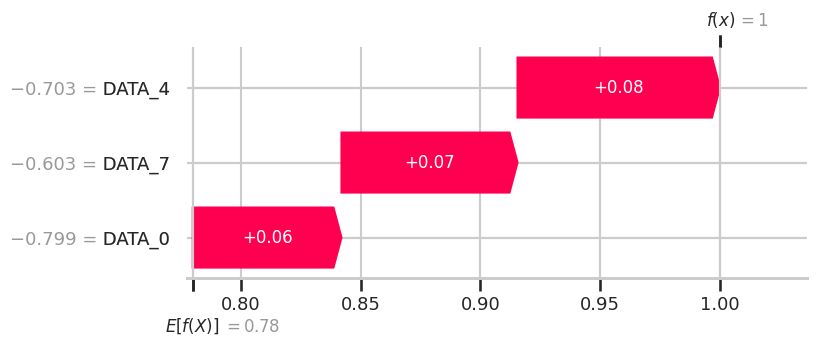

In [23]:
base_val = explainer.expected_value
if isinstance(base_val, (list, np.ndarray)):
    base_val = base_val[0]

exp = shap.Explanation(
    values=sv,
    base_values=base_val,
    data=X_shap[i],
    feature_names=feature_names
)

shap.plots.waterfall(exp)

In [28]:
# MULTI-CLASS SHAP (SAFE)


print("\n=== CLASS-WISE SHAP IMPORTANCE ===")

if isinstance(shap_values, list):  # XGBoost / RF multiclass case

    for c in range(len(shap_values)):
        print(f"\nClass {c}")

        imp = np.mean(np.abs(shap_values[c]), axis=0)

        df = pd.DataFrame({
            "Feature": feature_names,
            "Importance": imp
        }).sort_values("Importance", ascending=False)

        print(df.head(5))

else:
    print("Not a multi-class SHAP list → using single SHAP matrix")

    imp = np.mean(np.abs(shap_matrix), axis=0)

    df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": imp
    }).sort_values("Importance", ascending=False)

    print(df.head(5))


=== CLASS-WISE SHAP IMPORTANCE ===
Not a multi-class SHAP list → using single SHAP matrix
  Feature  Importance
0  DATA_0    0.108481
1  DATA_4    0.102532
2  DATA_7    0.088220



=== LIME ===
LIME explainer ready.

Instance 0 | True: 0 | Predicted: 0
[('DATA_7 <= -0.60', 0.046816501363561455), ('-0.61 < DATA_4 <= 0.63', -0.04239825024730289), ('-0.62 < DATA_0 <= 0.63', 0.038342403794264915)]


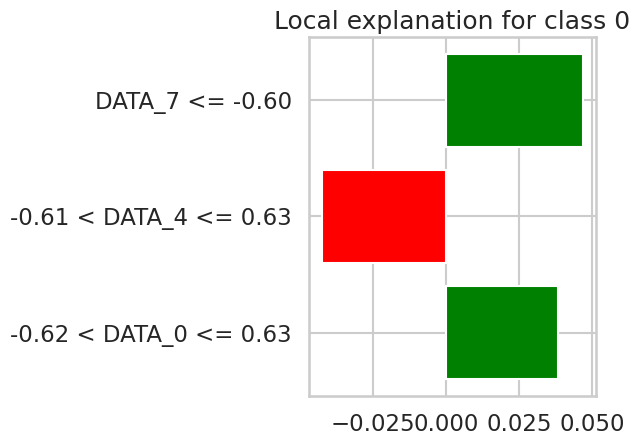


Instance 1 | True: 0 | Predicted: 0
[('-0.60 < DATA_7 <= 0.20', -0.19136610918997404), ('-0.61 < DATA_4 <= 0.63', -0.05212019040123078), ('DATA_0 > 0.63', -0.009500938106013952)]


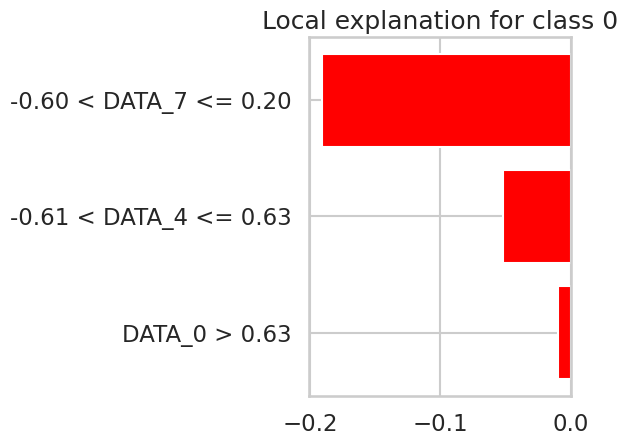


Instance 2 | True: 0 | Predicted: 0
[('DATA_7 <= -0.60', 0.057120785513856326), ('DATA_4 <= -0.70', 0.02852570151275585), ('DATA_0 > 0.63', -0.012614185950991477)]


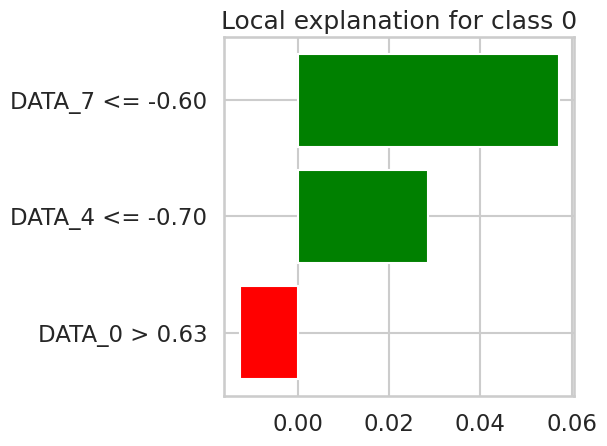


Instance 3 | True: 1 | Predicted: 1
[('-0.80 < DATA_0 <= -0.62', 0.09910903757915525), ('-0.61 < DATA_4 <= 0.63', 0.014834150744274929), ('DATA_7 <= -0.60', -0.004999350724932865)]


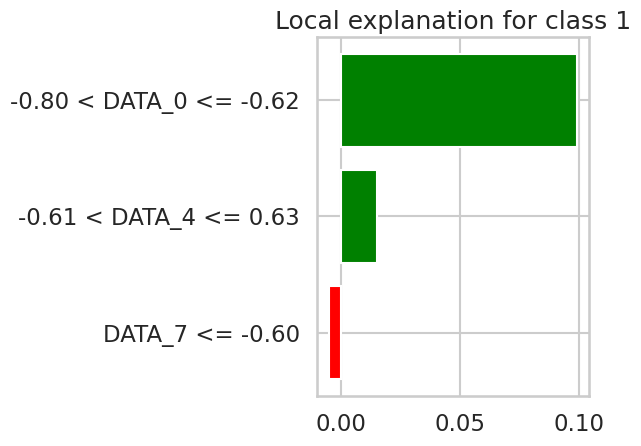


Instance 4 | True: 0 | Predicted: 0
[('-0.80 < DATA_0 <= -0.62', -0.07391480944981928), ('DATA_7 <= -0.60', 0.05345238799091052), ('DATA_4 <= -0.70', 0.039194189220642224)]


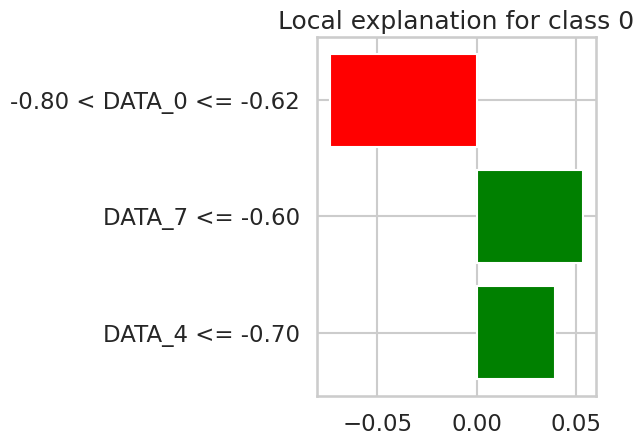

In [76]:
# LIME

print("\n=== LIME ===")

if 'classes_arr' not in locals():
    if 'preproc' not in locals():
        base_path = "/content/drive/MyDrive/CIC_IOV_2024"
        artifacts_dir = os.path.join(base_path, "artifacts")
        preproc = np.load(os.path.join(artifacts_dir, "full_split.npz"), allow_pickle=True)
    classes_arr = preproc["classes"] if "classes" in preproc.files else np.unique(y_train)


lime_explainer = LimeTabularExplainer(
    training_data=X_train_final,
    feature_names=feature_names, # Use the globally available 'feature_names'
    class_names=[str(c) for c in classes_arr],
    mode="classification",
    discretize_continuous=True,
    random_state=42
)

print("LIME explainer ready.")

for i in range(min(5, len(X_test_final))):
    data_instance = X_test_final[i]
    true_label = y_test[i]
    predicted_label = model.predict(data_instance.reshape(1, -1))[0]

    exp = lime_explainer.explain_instance(
        data_row=data_instance,
        predict_fn=model.predict_proba,
        num_features=len(feature_names), # Explain all selected features
        top_labels=1
    )

    print(f"\nInstance {i} | True: {true_label} | Predicted: {predicted_label}")
    top_label_idx = exp.available_labels()[0]
    print(exp.as_list(label=top_label_idx))

    fig = exp.as_pyplot_figure(label=top_label_idx)
    plt.tight_layout()
    plt.show()


In [78]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lime.lime_tabular import LimeTabularExplainer

np.random.seed(42)

print("Using PSO-selected features only:")
print(feature_names)

Using PSO-selected features only:
['DATA_0', 'DATA_4', 'DATA_7']


In [70]:
import joblib

if 'BASE_DIR' not in locals():
    BASE_DIR = "/content/drive/MyDrive/CIC_IOV_2024"
artifacts_dir = os.path.join(BASE_DIR, "artifacts")

# Load original full feature names from full_split.npz
original_full_data_info = np.load(os.path.join(artifacts_dir, "full_split.npz"), allow_pickle=True)
all_feature_names = original_full_data_info["feature_names"].tolist()

# Load the data split which already contains the feature-selected data
preproc = np.load(os.path.join(artifacts_dir, "data_split.npz"), allow_pickle=True)

# AUTO LOAD KEYS for already feature-selected data (X_train_final, X_test_final for LIME)
X_train_final = preproc['X_train']
X_test_final = preproc['X_test']
y_train = preproc['y_train']
y_test = preproc['y_test']

# Load feature selection info
features = np.load(os.path.join(artifacts_dir, "final_features.npz"), allow_pickle=True)
selected_features = features["final_features"].tolist() # This is ['DATA_0', 'DATA_4', 'DATA_7']

# The feature names for LIME are the selected ones
feature_names = selected_features


model_path = "/content/drive/MyDrive/CIC_IOV_2024/models/RandomForest/RandomForest.pkl"
model = joblib.load(model_path)

print("Features:", feature_names)

Features: ['DATA_0', 'DATA_4', 'DATA_7']


In [60]:
class_names = [str(i) for i in np.unique(y_train)]

lime_explainer = LimeTabularExplainer(
    training_data=X_train_final,
    feature_names=feature_names,
    class_names=class_names,
    mode="classification",
    discretize_continuous=True,
    random_state=42
)

print("LIME explainer ready")

LIME explainer ready


In [77]:
i = 0

exp = lime_explainer.explain_instance(
    data_row=X_test_final[i],
    predict_fn=model.predict_proba,
    num_features=min(10, len(feature_names)),
    top_labels=1
)

label = exp.available_labels()[0]

print(f"\nInstance {i}")
print("True:", y_test[i])
print("Pred:", model.predict(X_test_final[i].reshape(1, -1))[0])

print("\nLIME Explanation:")
print(exp.as_list(label=label))


Instance 0
True: 0
Pred: 0

LIME Explanation:
[('DATA_7 <= -0.60', 0.05411775907079082), ('-0.61 < DATA_4 <= 0.63', -0.05210458257408583), ('-0.62 < DATA_0 <= 0.63', 0.03589845540637803)]



=== MULTIPLE INSTANCE ANALYSIS ===

Instance 0 | True=0 | Pred=0
[('DATA_7 <= -0.60', 0.056179293974342924), ('-0.61 < DATA_4 <= 0.63', -0.051110836789577514), ('-0.62 < DATA_0 <= 0.63', 0.04307297515885611)]


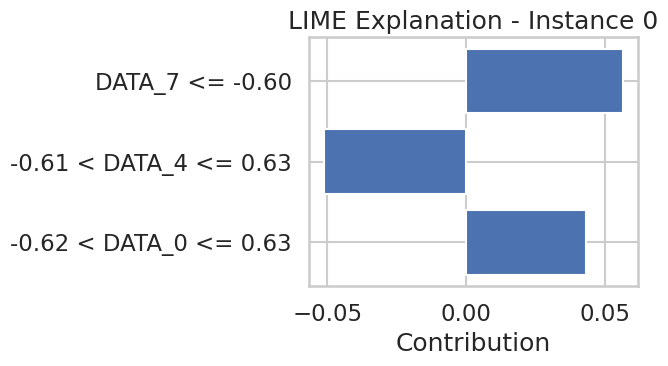


Instance 1 | True=0 | Pred=0
[('-0.60 < DATA_7 <= 0.20', -0.18462806681877203), ('-0.61 < DATA_4 <= 0.63', -0.048316289097116015), ('DATA_0 > 0.63', -0.011291935489628214)]


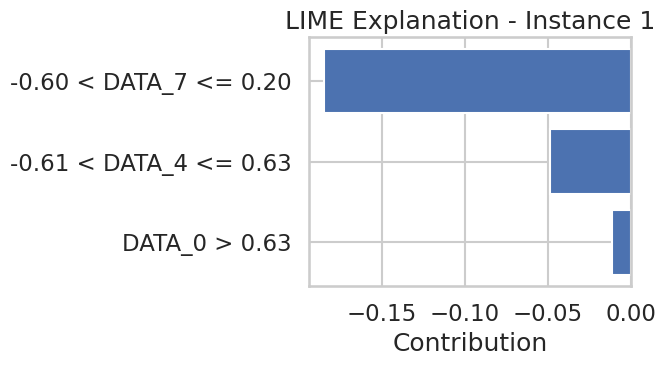


Instance 2 | True=0 | Pred=0
[('DATA_7 <= -0.60', 0.05633930233776982), ('DATA_4 <= -0.70', 0.03807482679213002), ('DATA_0 > 0.63', -0.010013880166491372)]


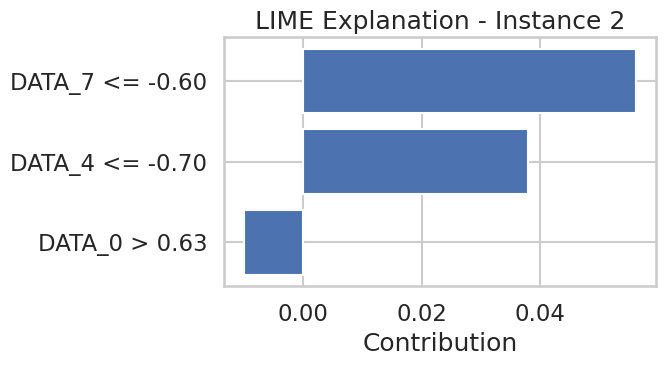

In [80]:
print("\n=== MULTIPLE INSTANCE ANALYSIS ===")

for i in range(3):

    exp = lime_explainer.explain_instance(
        data_row=X_test_final[i],
        predict_fn=model.predict_proba,
        num_features=len(feature_names),
        top_labels=1
    )

    label = exp.available_labels()[0]
    items = exp.as_list(label=label)

    print(f"\nInstance {i} | True={y_test[i]} | Pred={model.predict(X_test_final[i].reshape(1, -1))[0]}")
    print(items)

    f = [x[0] for x in items]
    w = [x[1] for x in items]

    plt.figure(figsize=(7, 4))
    plt.barh(f[::-1], w[::-1])
    plt.title(f"LIME Explanation - Instance {i}")
    plt.xlabel("Contribution")
    plt.tight_layout()
    plt.show()

In [81]:
print("\n=== LIME STABILITY CHECK ===")

i = 0

for run in range(3):

    exp = lime_explainer.explain_instance(
        data_row=X_test_final[i],
        predict_fn=model.predict_proba,
        num_features=len(feature_names),
        top_labels=1
    )

    label = exp.available_labels()[0]

    print(f"\nRun {run+1}")
    print(exp.as_list(label=label))


=== LIME STABILITY CHECK ===

Run 1
[('DATA_7 <= -0.60', 0.04567389339984782), ('-0.62 < DATA_0 <= 0.63', 0.040381512349151064), ('-0.61 < DATA_4 <= 0.63', -0.03748829372269609)]

Run 2
[('DATA_7 <= -0.60', 0.05713944154495974), ('-0.61 < DATA_4 <= 0.63', -0.052380521146440685), ('-0.62 < DATA_0 <= 0.63', 0.04517893547309621)]

Run 3
[('DATA_7 <= -0.60', 0.05189265076629647), ('-0.61 < DATA_4 <= 0.63', -0.044141560939210234), ('-0.62 < DATA_0 <= 0.63', 0.04291917161703178)]



=== GLOBAL LIME IMPORTANCE (PSO FEATURES) ===
  Feature  Importance
2  DATA_7    0.059676
0  DATA_0    0.043745
1  DATA_4    0.041941


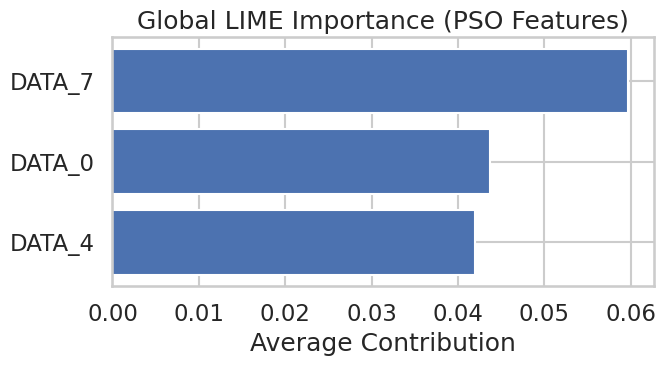

In [82]:
print("\n=== GLOBAL LIME IMPORTANCE (PSO FEATURES) ===")

importance_sum = np.zeros(len(feature_names))
n_samples = 50

for i in range(n_samples):

    exp = lime_explainer.explain_instance(
        data_row=X_test_final[i],
        predict_fn=model.predict_proba,
        num_features=len(feature_names),
        top_labels=1
    )

    label = exp.available_labels()[0]
    items = exp.as_list(label=label)

    for feat, val in items:
        for j, fname in enumerate(feature_names):
            if fname in feat:
                importance_sum[j] += abs(val)

importance_avg = importance_sum / n_samples

df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance_avg
}).sort_values("Importance", ascending=False)

print(df)

plt.figure(figsize=(7, 4))
plt.barh(df["Feature"][::-1], df["Importance"][::-1])
plt.title("Global LIME Importance (PSO Features)")
plt.xlabel("Average Contribution")
plt.tight_layout()
plt.show()